In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#**LDA METHOD GENSIM**

**ATAS INI - CONNECT TO GDRIVE**

**READ DATA**

In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/dataTA/Data_TA/dataset_TA.csv'
df_test = pd.read_csv(path)
df_test.head()


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1871423032138600659,2024-12-24T05:09:54.000Z,645,"Aku rela ikut lomba lari keliling dunia, asalk...",1871423032138600659,https://pbs.twimg.com/media/GfihUDibkAAc6xK.jpg,NaN,in,NaN,0,16,72,https://x.com/jevolante_id/status/187142303213...,1850425341938118656,jevolante_id
1,1871065733217808687,2024-12-23T05:30:08.000Z,3131,･ ｡ ❄\n ❄∴｡ *\n ･ﾟ*｡🌨･❄\n ❄･ *ﾟ｡ *\n 🌨･ ﾟ*｡･...,1871065733217808687,https://pbs.twimg.com/media/GfdcXi_bsAAKN0D.jpg,NaN,ja,NaN,10,2,645,https://x.com/semangkukuji/status/187106573321...,1726972094074982400,semangkukuji
2,1869329304250949863,2024-12-18T10:30:11.000Z,1137,Ini game apa lagiii 😭🙏🏻\n\n🕗: 20.00 WIB (GMT+7...,1869329304250949863,https://pbs.twimg.com/media/GfExFZPaIAA3aq-.jpg,NaN,in,NaN,8,60,138,https://x.com/MikazukiArion/status/18693293042...,1620372191287328769,MikazukiArion
3,1866004905602801880,2024-12-09T06:20:12.000Z,472,pompom! AS hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂...,1866004905602801880,https://pbs.twimg.com/media/GeVhknxW4AALmB3.jpg,NaN,in,NaN,49,50,24,https://x.com/pompomfess/status/18660049056028...,1639968630007029761,pompomfess
4,1871499564848763014,2024-12-24T10:14:01.000Z,1361,Lapak Gaming \nhttps://t.co/JqOwhR1C8B\n\nIndo...,1871499564848763014,https://pbs.twimg.com/media/GfjmzC4agAEasgn.jpg,NaN,in,NaN,4,42,275,https://x.com/dlayyyyyyyy/status/1871499564848...,1530862213379985408,dlayyyyyyyy


Cek english (kalo mau run ini, run preprocess dulu)

In [ ]:
from nltk.corpus import wordnet

def english_ratio(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0
    english_words = sum(1 for w in words if wordnet.synsets(w))
    return english_words / len(words)

ratios = df_test['full_text'].apply(english_ratio)

print("Rata-rata rasio Inggris:", ratios.mean())

LookupError: 
**********************************************************************
  Resource [93mwordnet[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('wordnet')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/wordnet[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
from nltk.corpus import wordnet

def english_ratio(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0
    english_words = sum(1 for w in words if wordnet.synsets(w))
    return english_words / len(words)

# Hitung rasio
df_test['english_ratio'] = df_test['full_text'].apply(english_ratio)

# Tentukan threshold (misal 0.3)
threshold = 0.3

# Filter tweet dengan rasio Inggris >= threshold
english_tweets = df_test[df_test['english_ratio'] >= threshold]

# Tampilkan indeks dan kolom full_text saja
english_tweets[['full_text']]

,full_text
13,คริสต์มาสนี้ไม่ต้องกลัวเหงา เตรียมพบกับ “ แซนต...
17,TROFI x Circus Collection Fall Winter 2024🎪🎠\n...
25,Kena mengucap jap tengok list diri sendiri\n\n...
30,sepatu sneakers idea\n\na thread\n\nrekomendas...
32,Kecintaanku pada lari dimulai sejak aku berusi...
...,...
4885,"You can’t lose weight at one particular spot, ..."
4886,The Residential Program at Chellaram Ultra Wel...
4887,You’re simply training for muscular endurance ...
4888,The strength of Equity Group Foundation #Equit...


In [ ]:
print("Jumlah tweet dengan dominasi Inggris:", len(english_tweets))
print("Index tweet tersebut:")
print(english_tweets.index.tolist())

Jumlah tweet dengan dominasi Inggris: 1231
Index tweet tersebut:
[13, 17, 25, 30, 32, 40, 41, 48, 49, 63, 70, 75, 80, 89, 119, 148, 154, 170, 181, 187, 190, 194, 195, 200, 211, 213, 218, 224, 225, 226, 228, 229, 231, 233, 234, 237, 238, 241, 245, 252, 257, 265, 266, 269, 271, 272, 275, 276, 283, 287, 288, 291, 299, 303, 308, 309, 315, 329, 330, 336, 342, 357, 360, 371, 374, 377, 391, 402, 404, 412, 416, 418, 421, 428, 436, 442, 456, 472, 474, 476, 483, 485, 487, 493, 495, 503, 506, 547, 548, 549, 550, 553, 562, 572, 577, 578, 590, 592, 594, 596, 598, 599, 602, 605, 606, 607, 612, 617, 622, 632, 633, 634, 636, 652, 666, 670, 677, 678, 688, 705, 718, 730, 731, 734, 742, 743, 744, 746, 747, 748, 769, 770, 775, 778, 779, 780, 785, 792, 794, 798, 807, 815, 816, 826, 830, 831, 835, 838, 850, 861, 863, 878, 897, 903, 906, 921, 932, 935, 936, 941, 942, 943, 950, 955, 962, 963, 964, 965, 968, 969, 970, 972, 973, 977, 978, 979, 983, 985, 988, 989, 993, 995, 998, 1001, 1003, 1007, 1010, 1012, 101

**Data preprocessing**

In [ ]:
# Ambil kolom teks saja
text = df_test['full_text'].astype(str)
print("Jumlah tweet:", len(text))
text.head()

Jumlah tweet: 4890


,full_text
0,"Aku rela ikut lomba lari keliling dunia, asalk..."
1,･ ｡ ❄\n ❄∴｡ *\n ･ﾟ*｡🌨･❄\n ❄･ *ﾟ｡ *\n 🌨･ ﾟ*｡･...
2,Ini game apa lagiii 😭🙏🏻\n\n🕗: 20.00 WIB (GMT+7...
3,pompom! AS hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂...
4,Lapak Gaming \nhttps://t.co/JqOwhR1C8B\n\nIndo...


In [ ]:
# Cek panjang karakter
text_length = df_test['full_text'].str.len()
print(text_length.describe())

count    4890.000000
mean      169.404908
std        85.408740
min         4.000000
25%        94.000000
50%       163.500000
75%       250.000000
max       749.000000
Name: full_text, dtype: float64


In [ ]:
# Drop missing
df_test = df_test.dropna(subset=['full_text'])

# Ambil kolom teks
text = df_test['full_text'].astype(str)

print("Jumlah tweet:", len(text))
print("Contoh data:")
print(text.head())

Jumlah tweet: 4890
Contoh data:
0    Aku rela ikut lomba lari keliling dunia, asalk...
1    ･ ｡ ❄\n ❄∴｡　*\n　･ﾟ*｡🌨･❄\n　　❄･ *ﾟ｡　 *\n　🌨･ ﾟ*｡･...
2    Ini game apa lagiii 😭🙏🏻\n\n🕗: 20.00 WIB (GMT+7...
3    pompom! AS hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂...
4    Lapak Gaming \nhttps://t.co/JqOwhR1C8B\n\nIndo...
Name: full_text, dtype: object


**2️⃣ Preprocessing (Lowercase, Cleaning, Tokenizing, Stopwords, Lemmatization & Stemming)**

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.5 MB/s eta 0:00:00


**pakai wordnet** (bukan ini yg di run)

-➡️ Mengubah kata ke lemma (bentuk dasar) berdasarkan kamus bahasa Inggris.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))
lemmatizer = WordNetLemmatizer()
stemmer = StemmerFactory().create_stemmer()



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Tidak pakai wordnet Untuk english** coba yang ini dulu - ini yang di run

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Download resource yang diperlukan
nltk.download('punkt')
nltk.download('stopwords')

# Stopword Bahasa Indonesia (dasar)
stop_words = set(stopwords.words('indonesian'))

# Stemmer Bahasa Indonesia
stemmer = StemmerFactory().create_stemmer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**🧩 STEP 1 — Lowercasing**

In [ ]:
# Tambahkan kolom baru langsung di df_test
df_test['lower'] = df_test['full_text'].astype(str).str.lower()

for i in range(5):
    print(f"\n--- Tweet {i+1} ---")
    print("Original :", df_test['full_text'].iloc[i])
    print("Lower    :", df_test['lower'].iloc[i])

df_test.head(15)



--- Tweet 1 ---
Original : Aku rela ikut lomba lari keliling dunia, asalkan engkau yang menjadi garis finishnya. 🥰❤
#GombalanGaul #Cintaku #Sayangku #Cinta #Love #Wow #Cantik #MauGakJadiPacarku #JKT48Cantik #fyp https://t.co/Ix8NyuRwXU
Lower    : aku rela ikut lomba lari keliling dunia, asalkan engkau yang menjadi garis finishnya. 🥰❤
#gombalangaul #cintaku #sayangku #cinta #love #wow #cantik #maugakjadipacarku #jkt48cantik #fyp https://t.co/ix8nyurwxu

--- Tweet 2 ---
Original : ･ ｡ ❄
 ❄∴｡　*
　･ﾟ*｡🌨･❄
　　❄･ *ﾟ｡　 *
　🌨･ ﾟ*｡･ﾟ❄｡  
　　　🌨･｡°*. ﾟ
　　❄ﾟ｡·*･｡ ﾟ*  ❄
　　　ﾟ *.｡❄｡･  
　　* 🌨 ｡･ﾟ*.｡ ❄
　　　 *　❄ 🌨 *  ｡
　　　　🌨･　　ﾟ❄  ｡❄ https://t.co/sGtu0HCbjT
Lower    : ･ ｡ ❄
 ❄∴｡　*
　･ﾟ*｡🌨･❄
　　❄･ *ﾟ｡　 *
　🌨･ ﾟ*｡･ﾟ❄｡  
　　　🌨･｡°*. ﾟ
　　❄ﾟ｡·*･｡ ﾟ*  ❄
　　　ﾟ *.｡❄｡･  
　　* 🌨 ｡･ﾟ*.｡ ❄
　　　 *　❄ 🌨 *  ｡
　　　　🌨･　　ﾟ❄  ｡❄ https://t.co/sgtu0hcbjt

--- Tweet 3 ---
Original : Ini game apa lagiii 😭🙏🏻

🕗: 20.00 WIB (GMT+7)
🗓️: Wed, 18 Dec 2024
🌒: https://t.co/oXQQRacpBZ

#onairion #SOL4CE https://t.co/3djXPYjzRY
Lower    : ini game a

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,lower
0,1871423032138600659,2024-12-24T05:09:54.000Z,645,"Aku rela ikut lomba lari keliling dunia, asalk...",1871423032138600659,https://pbs.twimg.com/media/GfihUDibkAAc6xK.jpg,NaN,in,NaN,0,16,72,https://x.com/jevolante_id/status/187142303213...,1850425341938118656,jevolante_id,"aku rela ikut lomba lari keliling dunia, asalk..."
1,1871065733217808687,2024-12-23T05:30:08.000Z,3131,･ ｡ ❄\n ❄∴｡ *\n ･ﾟ*｡🌨･❄\n ❄･ *ﾟ｡ *\n 🌨･ ﾟ*｡･...,1871065733217808687,https://pbs.twimg.com/media/GfdcXi_bsAAKN0D.jpg,NaN,ja,NaN,10,2,645,https://x.com/semangkukuji/status/187106573321...,1726972094074982400,semangkukuji,･ ｡ ❄\n ❄∴｡ *\n ･ﾟ*｡🌨･❄\n ❄･ *ﾟ｡ *\n 🌨･ ﾟ*｡･...
2,1869329304250949863,2024-12-18T10:30:11.000Z,1137,Ini game apa lagiii 😭🙏🏻\n\n🕗: 20.00 WIB (GMT+7...,1869329304250949863,https://pbs.twimg.com/media/GfExFZPaIAA3aq-.jpg,NaN,in,NaN,8,60,138,https://x.com/MikazukiArion/status/18693293042...,1620372191287328769,MikazukiArion,ini game apa lagiii 😭🙏🏻\n\n🕗: 20.00 wib (gmt+7...
3,1866004905602801880,2024-12-09T06:20:12.000Z,472,pompom! AS hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂...,1866004905602801880,https://pbs.twimg.com/media/GeVhknxW4AALmB3.jpg,NaN,in,NaN,49,50,24,https://x.com/pompomfess/status/18660049056028...,1639968630007029761,pompomfess,pompom! as hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂...
4,1871499564848763014,2024-12-24T10:14:01.000Z,1361,Lapak Gaming \nhttps://t.co/JqOwhR1C8B\n\nIndo...,1871499564848763014,https://pbs.twimg.com/media/GfjmzC4agAEasgn.jpg,NaN,in,NaN,4,42,275,https://x.com/dlayyyyyyyy/status/1871499564848...,1530862213379985408,dlayyyyyyyy,lapak gaming \nhttps://t.co/jqowhr1c8b\n\nindo...
5,1867791139283382666,2024-12-14T04:38:04.000Z,216,📣Pengumuman Trending\n\nMacau siap jadi saksi ...,1867791139283382666,https://pbs.twimg.com/media/Geu6I1NasAA5ZXi.jpg,NaN,in,NaN,1,0,73,https://x.com/LingOrm_ID/status/18677911392833...,1818635495683112961,LingOrm_ID,📣pengumuman trending\n\nmacau siap jadi saksi ...
6,1870802636330676255,2024-12-22T12:04:40.000Z,501,ARE YOU READY TO WITNESS THE ULTIMATE CHALLENG...,1870802636330676255,https://pbs.twimg.com/ext_tw_video_thumb/18708...,NaN,in,NaN,123,29,173,https://x.com/ruangguru/status/187080263633067...,457341503,ruangguru,are you ready to witness the ultimate challeng...
7,1873721105170768100,2024-12-30T13:21:38.000Z,1958,Terima kasih ya Gen 12 sudah mewarnai hari har...,1873721105170768100,https://pbs.twimg.com/amplify_video_thumb/1873...,NaN,in,NaN,6,2,589,https://x.com/dlayyyyyyyy/status/1873721105170...,1530862213379985408,dlayyyyyyyy,terima kasih ya gen 12 sudah mewarnai hari har...
8,1871731575710437868,2024-12-25T01:35:57.000Z,948,"[SCHEDULE] Hari ini Rabu, 25 Desember\n\n📺: SB...",1871731575710437868,https://pbs.twimg.com/media/Gfm58pzbIAA_veC.jpg,NaN,in,NaN,10,1,283,https://x.com/Renjun323_ID/status/187173157571...,1139092334086242305,Renjun323_ID,"[schedule] hari ini rabu, 25 desember\n\n📺: sb..."
9,1870352854839648698,2024-12-21T06:17:24.000Z,710,"Ada geng yang lari bukan sebab nak fit, tapi s...",1870352854839648698,https://pbs.twimg.com/media/GfTUAP-bgAAcVPY.jpg,NaN,in,NaN,98,15,445,https://x.com/Cikgu_Anep/status/18703528548396...,886368824,Cikgu_Anep,"ada geng yang lari bukan sebab nak fit, tapi s..."


In [ ]:
# Ambil kolom lower saja
text1 = df_test['lower'].astype(str)
print("Jumlah tweet:", len(text1))
text1.head()


Jumlah tweet: 4890


,lower
0,"aku rela ikut lomba lari keliling dunia, asalk..."
1,･ ｡ ❄\n ❄∴｡ *\n ･ﾟ*｡🌨･❄\n ❄･ *ﾟ｡ *\n 🌨･ ﾟ*｡･...
2,ini game apa lagiii 😭🙏🏻\n\n🕗: 20.00 wib (gmt+7...
3,pompom! as hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂...
4,lapak gaming \nhttps://t.co/jqowhr1c8b\n\nindo...


**🧹 STEP 2 — Cleaning (hapus URL, mention, hashtag, simbol, angka)**

🔹 Tujuan: hapus noise (link, mention, angka, emoji, simbol).
🔹 Setelah ini teks harus lebih “bersih”.

**INI TIDAK DI RUN**

In [ ]:
#versi 1 menghilangkan angka

import re
import pandas as pd

# fungsi cleaning
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)   # hapus URL
    text = re.sub(r"@\w+", "", text)                      # hapus mention
    text = re.sub(r"#\w+", "", text)                      # hapus hashtag
    text = re.sub(r"[^a-zA-Z\s]", " ", text)              # hapus simbol, angka
    text = re.sub(r"\s+", " ", text).strip()              # hapus spasi berlebih
    return text

# terapkan fungsi cleaning
text2 = text1.apply(clean_text)

# gabungkan hasil ke dalam DataFrame untuk perbandingan
compare_df = pd.DataFrame({
    'Before (Lowercase)': text1,
    'After (Cleaned)': text2
})

# tampilkan 5 data pertama dalam tabel
print("🧹 Hasil Cleaning (Before → After):\n")
display(compare_df.head(10))

# tampilkan juga versi print untuk melihat langsung
for i in range(10):
    print(f"\n--- Tweet {i+1} ---")
    print("Before:", text1.iloc[i])
    print("After :", text2.iloc[i])


🧹 Hasil Cleaning (Before → After):



,Before (Lowercase),After (Cleaned)
0,"aku rela ikut lomba lari keliling dunia, asalk...",aku rela ikut lomba lari keliling dunia asalka...
1,･ ｡ ❄\n ❄∴｡ *\n ･ﾟ*｡🌨･❄\n ❄･ *ﾟ｡ *\n 🌨･ ﾟ*｡･...,
2,ini game apa lagiii 😭🙏🏻\n\n🕗: 20.00 wib (gmt+7...,ini game apa lagiii wib gmt wed dec
3,pompom! as hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂...,pompom as hari ini
4,lapak gaming \nhttps://t.co/jqowhr1c8b\n\nindo...,lapak gaming indonesia game festival scarlett ...
5,📣pengumuman trending\n\nmacau siap jadi saksi ...,pengumuman trending macau siap jadi saksi kisa...
6,are you ready to witness the ultimate challeng...,are you ready to witness the ultimate challeng...
7,terima kasih ya gen 12 sudah mewarnai hari har...,terima kasih ya gen sudah mewarnai hari hariku...
8,"[schedule] hari ini rabu, 25 desember\n\n📺: sb...",schedule hari ini rabu desember sbs gayo daeje...
9,"ada geng yang lari bukan sebab nak fit, tapi s...",ada geng yang lari bukan sebab nak fit tapi se...



--- Tweet 1 ---
Before: aku rela ikut lomba lari keliling dunia, asalkan engkau yang menjadi garis finishnya. 🥰❤
#gombalangaul #cintaku #sayangku #cinta #love #wow #cantik #maugakjadipacarku #jkt48cantik #fyp https://t.co/ix8nyurwxu
After : aku rela ikut lomba lari keliling dunia asalkan engkau yang menjadi garis finishnya

--- Tweet 2 ---
Before: ･ ｡ ❄
 ❄∴｡　*
　･ﾟ*｡🌨･❄
　　❄･ *ﾟ｡　 *
　🌨･ ﾟ*｡･ﾟ❄｡  
　　　🌨･｡°*. ﾟ
　　❄ﾟ｡·*･｡ ﾟ*  ❄
　　　ﾟ *.｡❄｡･  
　　* 🌨 ｡･ﾟ*.｡ ❄
　　　 *　❄ 🌨 *  ｡
　　　　🌨･　　ﾟ❄  ｡❄ https://t.co/sgtu0hcbjt
After : 

--- Tweet 3 ---
Before: ini game apa lagiii 😭🙏🏻

🕗: 20.00 wib (gmt+7)
🗓️: wed, 18 dec 2024
🌒: https://t.co/oxqqracpbz

#onairion #sol4ce https://t.co/3djxpyjzry
After : ini game apa lagiii wib gmt wed dec

--- Tweet 4 ---
Before: pompom! as hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂 https://t.co/nn0ek8ictq
After : pompom as hari ini

--- Tweet 5 ---
Before: lapak gaming 
https://t.co/jqowhr1c8b

indonesia game festival 2024 
http

**ini yang di RUN**

In [ ]:
#tidak menghilangkan angka semantik (5k 10k 21k 42k)

import re
import pandas as pd

def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)   # hapus URL
    text = re.sub(r"@\w+", "", text)                      # hapus mention
    text = re.sub(r"#", "", text)                         # hapus simbol # saja

    # Pertahankan pola seperti 5k, 10k, 21k, 42k
    text = re.sub(r"\b(\d+)(?=[a-zA-Z])", r"\1", text)   # pertahankan angka jika diikuti huruf

    # Hapus simbol selain huruf, angka, dan spasi
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Hapus angka yang berdiri sendiri (misal: 2024, 123)
    text = re.sub(r"\b\d+\b", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

# Terapkan cleaning
text2 = text1.apply(clean_text)

# gabungkan hasil ke dalam DataFrame untuk perbandingan
compare_df = pd.DataFrame({
    'Before (Lowercase)': text1,
    'After (Cleaned)': text2
})

# tampilkan 5 data pertama dalam tabel
print("🧹 Hasil Cleaning (Before → After):\n")
display(compare_df.head(10))

# tampilkan juga versi print untuk melihat langsung
for i in range(10):
    print(f"\n--- Tweet {i+1} ---")
    print("Before:", text1.iloc[i])
    print("After :", text2.iloc[i])

🧹 Hasil Cleaning (Before → After):



,Before (Lowercase),After (Cleaned)
0,"aku rela ikut lomba lari keliling dunia, asalk...",aku rela ikut lomba lari keliling dunia asalka...
1,･ ｡ ❄\n ❄∴｡ *\n ･ﾟ*｡🌨･❄\n ❄･ *ﾟ｡ *\n 🌨･ ﾟ*｡･...,
2,ini game apa lagiii 😭🙏🏻\n\n🕗: 20.00 wib (gmt+7...,ini game apa lagiii wib gmt wed dec onairion s...
3,pompom! as hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂...,pompom as hari ini
4,lapak gaming \nhttps://t.co/jqowhr1c8b\n\nindo...,lapak gaming indonesia game festival scarlett ...
5,📣pengumuman trending\n\nmacau siap jadi saksi ...,pengumuman trending macau siap jadi saksi kisa...
6,are you ready to witness the ultimate challeng...,are you ready to witness the ultimate challeng...
7,terima kasih ya gen 12 sudah mewarnai hari har...,terima kasih ya gen sudah mewarnai hari hariku...
8,"[schedule] hari ini rabu, 25 desember\n\n📺: sb...",schedule hari ini rabu desember sbs gayo daeje...
9,"ada geng yang lari bukan sebab nak fit, tapi s...",ada geng yang lari bukan sebab nak fit tapi se...



--- Tweet 1 ---
Before: aku rela ikut lomba lari keliling dunia, asalkan engkau yang menjadi garis finishnya. 🥰❤
#gombalangaul #cintaku #sayangku #cinta #love #wow #cantik #maugakjadipacarku #jkt48cantik #fyp https://t.co/ix8nyurwxu
After : aku rela ikut lomba lari keliling dunia asalkan engkau yang menjadi garis finishnya gombalangaul cintaku sayangku cinta love wow cantik maugakjadipacarku jkt48cantik fyp

--- Tweet 2 ---
Before: ･ ｡ ❄
 ❄∴｡　*
　･ﾟ*｡🌨･❄
　　❄･ *ﾟ｡　 *
　🌨･ ﾟ*｡･ﾟ❄｡  
　　　🌨･｡°*. ﾟ
　　❄ﾟ｡·*･｡ ﾟ*  ❄
　　　ﾟ *.｡❄｡･  
　　* 🌨 ｡･ﾟ*.｡ ❄
　　　 *　❄ 🌨 *  ｡
　　　　🌨･　　ﾟ❄  ｡❄ https://t.co/sgtu0hcbjt
After : 

--- Tweet 3 ---
Before: ini game apa lagiii 😭🙏🏻

🕗: 20.00 wib (gmt+7)
🗓️: wed, 18 dec 2024
🌒: https://t.co/oxqqracpbz

#onairion #sol4ce https://t.co/3djxpyjzry
After : ini game apa lagiii wib gmt wed dec onairion sol4ce

--- Tweet 4 ---
Before: pompom! as hari ini 😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂😭😂 https://t.co/nn0ek8ictq
After : pompom as hari 

**🧩 STEP 3 — Tokenizing**

*   Tujuan: ubah string jadi list kata.
*    Misal "lari pagi seru banget" → ['lari','pagi','seru','banget'].



In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
 # fungsi tokenizing
def tokenize_text(text):
    return nltk.word_tokenize(text)

# terapkan fungsi
text3 = text2.apply(tokenize_text)

# gabungkan hasilnya ke DataFrame buat perbandingan
token_df = pd.DataFrame({
    'After (Cleaned)': text2,
    'After (Tokenized)': text3
})

# tampilkan hasilnya
print("🔤 Hasil Tokenizing (Cleaned → Tokenized):\n")
display(token_df.head(5))

# tampilkan contoh print
for i in range(5):
    print(f"\n--- Tweet {i+1} ---")
    print("Cleaned  :", text2.iloc[i])
    print("Tokenized:", text3.iloc[i])


🔤 Hasil Tokenizing (Cleaned → Tokenized):



,After (Cleaned),After (Tokenized)
0,aku rela ikut lomba lari keliling dunia asalka...,"[aku, rela, ikut, lomba, lari, keliling, dunia..."
1,,[]
2,ini game apa lagiii wib gmt wed dec onairion s...,"[ini, game, apa, lagiii, wib, gmt, wed, dec, o..."
3,pompom as hari ini,"[pompom, as, hari, ini]"
4,lapak gaming indonesia game festival scarlett ...,"[lapak, gaming, indonesia, game, festival, sca..."



--- Tweet 1 ---
Cleaned  : aku rela ikut lomba lari keliling dunia asalkan engkau yang menjadi garis finishnya gombalangaul cintaku sayangku cinta love wow cantik maugakjadipacarku jkt48cantik fyp
Tokenized: ['aku', 'rela', 'ikut', 'lomba', 'lari', 'keliling', 'dunia', 'asalkan', 'engkau', 'yang', 'menjadi', 'garis', 'finishnya', 'gombalangaul', 'cintaku', 'sayangku', 'cinta', 'love', 'wow', 'cantik', 'maugakjadipacarku', 'jkt48cantik', 'fyp']

--- Tweet 2 ---
Cleaned  : 
Tokenized: []

--- Tweet 3 ---
Cleaned  : ini game apa lagiii wib gmt wed dec onairion sol4ce
Tokenized: ['ini', 'game', 'apa', 'lagiii', 'wib', 'gmt', 'wed', 'dec', 'onairion', 'sol4ce']

--- Tweet 4 ---
Cleaned  : pompom as hari ini
Tokenized: ['pompom', 'as', 'hari', 'ini']

--- Tweet 5 ---
Cleaned  : lapak gaming indonesia game festival scarlett kokas chatime alam sutera tango ampera mng road to sousenkyo pestapora
Tokenized: ['lapak', 'gaming', 'indonesia', 'game', 'festival', 'scarlett', 'kokas', 'chatime', 'al

In [ ]:
# Mengukur panjang dokumen setelah tokenisasi.

print("Rata-rata jumlah token per dokumen:")
print(text3.apply(len).mean())

print("Min token:", text3.apply(len).min())
print("Max token:", text3.apply(len).max())

Rata-rata jumlah token per dokumen:
22.114314928425358
Min token: 0
Max token: 92


In [ ]:
# cek dokumen kosong karena min token : 0

empty_docs = text3[text3.apply(len) == 0]

print("Jumlah dokumen kosong:", len(empty_docs))

Jumlah dokumen kosong: 217


In [ ]:
empty_index = empty_docs.index

df_test.loc[empty_index, ['lower']].head(5)

,lower
1,･ ｡ ❄\n ❄∴｡ *\n ･ﾟ*｡🌨･❄\n ❄･ *ﾟ｡ *\n 🌨･ ﾟ*｡･...
165,⢀⡤⣄⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀\n⢠⡏⠀⠀⠳⡄⠀⠀⠀⠀⠀ ⣀⣀⣀⠀⠀⠀ \n⢸⠃⠀⠀⠀...
166,💚 🩷 ♥️ ♥️ 🩷 ...
167,🫳🏻\n* · ✵ \n ✨˚ ✷ *\n ✫ ✫ 🌟· ˚...
168,🩷 💚 🩷 💚 💚 🩷\...


In [ ]:
#drop dokumen kosong (empty)

# Simpan index valid (token > 0)
valid_index = text3[text3.apply(len) > 0].index

# Filter semua dataframe
df_test = df_test.loc[valid_index]
text3 = text3.loc[valid_index]

print("Jumlah data setelah drop kosong:", len(text3))

Jumlah data setelah drop kosong: 4673


In [ ]:
# Mengukur panjang dokumen setelah tokenisasi.

print("Rata-rata jumlah token per dokumen:")
print(text3.apply(len).mean())

print("Min token:", text3.apply(len).min())
print("Max token:", text3.apply(len).max())

Rata-rata jumlah token per dokumen:
23.14123689278836
Min token: 1
Max token: 92


In [ ]:
short_docs = text3[text3.apply(len) < 3]
print("Jumlah dokumen < 3 token:", len(short_docs))

Jumlah dokumen < 3 token: 138


In [ ]:
# Drop final token dibawah 3

valid_index = text3[text3.apply(len) >= 3].index

df_test = df_test.loc[valid_index]
text3 = text3.loc[valid_index]

print("Jumlah data setelah filter <3 token:", len(text3))

Jumlah data setelah filter <3 token: 4535


**Masukkan penjelasan ini ke skripsi?**

Dokumen dengan jumlah token kurang dari 3 dihapus dari dataset karena dianggap tidak memiliki konteks yang cukup untuk membentuk distribusi topik yang stabil dalam model LDA. LDA merupakan model probabilistik yang mengasumsikan setiap dokumen terdiri atas campuran beberapa topik. Dokumen dengan satu atau dua token cenderung menghasilkan distribusi topik yang tidak stabil serta meningkatkan sparsity dalam korpus. Oleh karena itu, penyaringan ini dilakukan untuk meningkatkan kualitas dan kestabilan model.

**🧯 STEP 4 — Stopword Removal**


*   🔹 Tujuan: buang kata umum yang tidak penting seperti “dan”, “di”, “yang”.



In [ ]:
# ambil stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# fungsi untuk hapus stopwords
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# terapkan ke hasil tokenizing
text4 = text3.apply(remove_stopwords)

# buat tabel perbandingan
stopword_df = pd.DataFrame({
    'After (Tokenized)': text3,
    'After (Stopword Removed)': text4
})

# tampilkan tabel hasil
print("🧹 Hasil Stopword Removal (Tokenized → Stopword Removed):\n")
display(stopword_df.head(50))

# tampilkan contoh detail
for i in range(5):
    print(f"\n--- Tweet {i+1} ---")
    print("Tokenized        :", text3.iloc[i])
    print("Stopword Removed :", text4.iloc[i])


🧹 Hasil Stopword Removal (Tokenized → Stopword Removed):



,After (Tokenized),After (Stopword Removed)
0,"[aku, rela, ikut, lomba, lari, keliling, dunia...","[rela, lomba, lari, keliling, dunia, engkau, g..."
2,"[ini, game, apa, lagiii, wib, gmt, wed, dec, o...","[game, lagiii, wib, gmt, wed, dec, onairion, s..."
3,"[pompom, as, hari, ini]","[pompom, as]"
4,"[lapak, gaming, indonesia, game, festival, sca...","[lapak, gaming, indonesia, game, festival, sca..."
5,"[pengumuman, trending, macau, siap, jadi, saks...","[pengumuman, trending, macau, saksi, kisah, ci..."
6,"[are, you, ready, to, witness, the, ultimate, ...","[are, you, ready, to, witness, the, ultimate, ..."
7,"[terima, kasih, ya, gen, sudah, mewarnai, hari...","[terima, kasih, ya, gen, mewarnai, hariku]"
8,"[schedule, hari, ini, rabu, desember, sbs, gay...","[schedule, rabu, desember, sbs, gayo, daejeon,..."
9,"[ada, geng, yang, lari, bukan, sebab, nak, fit...","[geng, lari, nak, fit, nak, makan, tag, dioran..."
10,"[pertarungan, manis, hampir, tiba, oreo, choco...","[pertarungan, manis, oreo, choco, hot, choco, ..."



--- Tweet 1 ---
Tokenized        : ['aku', 'rela', 'ikut', 'lomba', 'lari', 'keliling', 'dunia', 'asalkan', 'engkau', 'yang', 'menjadi', 'garis', 'finishnya', 'gombalangaul', 'cintaku', 'sayangku', 'cinta', 'love', 'wow', 'cantik', 'maugakjadipacarku', 'jkt48cantik', 'fyp']
Stopword Removed : ['rela', 'lomba', 'lari', 'keliling', 'dunia', 'engkau', 'garis', 'finishnya', 'gombalangaul', 'cintaku', 'sayangku', 'cinta', 'love', 'wow', 'cantik', 'maugakjadipacarku', 'jkt48cantik', 'fyp']

--- Tweet 2 ---
Tokenized        : ['ini', 'game', 'apa', 'lagiii', 'wib', 'gmt', 'wed', 'dec', 'onairion', 'sol4ce']
Stopword Removed : ['game', 'lagiii', 'wib', 'gmt', 'wed', 'dec', 'onairion', 'sol4ce']

--- Tweet 3 ---
Tokenized        : ['pompom', 'as', 'hari', 'ini']
Stopword Removed : ['pompom', 'as']

--- Tweet 4 ---
Tokenized        : ['lapak', 'gaming', 'indonesia', 'game', 'festival', 'scarlett', 'kokas', 'chatime', 'alam', 'sutera', 'tango', 'ampera', 'mng', 'road', 'to', 'sousenkyo', 'pestap

In [ ]:
print("Rata-rata token setelah stopword:", text4.apply(len).mean())
print("Min token:", text4.apply(len).min())
print("Max token:", text4.apply(len).max())

Rata-rata token setelah stopword: 18.61345093715546
Min token: 0
Max token: 92


In [ ]:
short_docs = text4[text4.apply(len) < 3]
print("Jumlah dokumen < 3 token setelah stopword:", len(short_docs))

Jumlah dokumen < 3 token setelah stopword: 19


In [ ]:
# Drop final token dibawah 3

valid_index = text4[text4.apply(len) >= 3].index

df_test = df_test.loc[valid_index]
text4 = text4.loc[valid_index]

print("Jumlah data final setelah stopword filtering:", len(text4))

Jumlah data final setelah stopword filtering: 4516


In [ ]:
# ambil stopwords bawaan
stop_words = set(stopwords.words('indonesian'))

# tambahkan stopwords Inggris
stop_words.update(stopwords.words('english'))

# tambahkan versi informal
custom_stopwords = [
    'yg', 'aja', 'jg', 'bgt', 'banget',
    'ga', 'gak', 'enggak', 'kalo', 'kalau', 'klo',
    'nya', 'sih', 'dong', 'ko', 'loh',
    'ya', 'lho', 'lah', 'buat', 'biar', 'ok', 'oke',
    'udah', 'sudah', 'kayak', 'kayaknya', 'nih', 'tuh', 'deh',
    'gt', 'utk', 'ni', 'nak','amp','dlm','m','a','tp','lo',
    'gue','gua','gw','de','n','b','e','eu','que','r','na','cr',
    'ak','l','p','g','u','w','q','em',
    'kek','krn','jd','dah','da','tu','lg','dr','trs','sm','kl',
    'dll','si','eh','la','te',
    'wkwk','wkwkwk','wkwkw',
    'com','link','co', 'deu', 'meu', 'agora', 'uma', 'jol','pai',
    'je','nao','quero','lovato','faker','loiro','aitor','larry','fiquei',
    'tent','udh','lu','skrg','yuk','yaa','mah','dur','lingorm','adadikompas',
    'trus','el','amo','gara','iya','vc','kak','ngga','h','nge','es'

]

# gabungkan stopwords
stop_words.update(custom_stopwords)

# re-run stopword removal
text4 = text3.apply(lambda tokens: [w for w in tokens if w not in stop_words])

# cek ulang top 10 kata
from collections import Counter
after_custom = [w for tokens in text4 for w in tokens]
print("🔹 Top 10 kata sesudah custom stopword:")
print(Counter(after_custom).most_common(1000))


🔹 Top 10 kata sesudah custom stopword:
[('lari', 3704), ('olahraga', 2158), ('fomo', 1374), ('sepatu', 456), ('jalan', 370), ('event', 319), ('run', 307), ('gym', 287), ('orang', 277), ('pagi', 252), ('kaki', 211), ('suka', 201), ('pas', 198), ('running', 197), ('training', 176), ('sehat', 163), ('pake', 161), ('jam', 154), ('beli', 148), ('harga', 147), ('shopee', 139), ('liat', 128), ('dapatkan', 128), ('bikin', 126), ('cek', 125), ('jogging', 125), ('minggu', 122), ('strength', 119), ('ikutan', 118), ('wanita', 114), ('pengen', 113), ('bagus', 111), ('sampe', 109), ('abis', 108), ('semangat', 103), ('badan', 100), ('nyaman', 99), ('km', 97), ('pria', 97), ('rutin', 95), ('tau', 94), ('emang', 92), ('asics', 92), ('gitu', 91), ('day', 90), ('padel', 89), ('coba', 88), ('program', 88), ('pelari', 87), ('tas', 87), ('latihan', 86), ('makan', 85), ('bareng', 85), ('marathon', 84), ('sport', 83), ('menit', 82), ('time', 82), ('org', 82), ('hidup', 81), ('main', 80), ('pace', 80), ('kali'

In [ ]:
print("Rata-rata panjang token sebelum stopword:", text3.apply(len).mean())
print("Rata-rata panjang token sesudah stopword:", text4.apply(len).mean())


Rata-rata panjang token sebelum stopword: 23.800220507166483
Rata-rata panjang token sesudah stopword: 14.792061742006615


In [ ]:
from collections import Counter

# Gabungkan semua token jadi satu list
before = [w for tokens in text3 for w in tokens]
after = [w for tokens in text4 for w in tokens]

print("🔹 Top 10 kata sebelum stopword:")
print(Counter(before).most_common(50))

print("\n🔹 Top 10 kata sesudah stopword:")
print(Counter(after).most_common(50))


🔹 Top 10 kata sebelum stopword:
[('lari', 3704), ('olahraga', 2158), ('fomo', 1374), ('di', 1084), ('dan', 962), ('yang', 936), ('ini', 841), ('yg', 697), ('aku', 618), ('the', 525), ('buat', 524), ('ga', 521), ('ada', 520), ('bisa', 502), ('a', 480), ('sepatu', 456), ('tapi', 450), ('ya', 441), ('aja', 433), ('itu', 412), ('lagi', 403), ('to', 398), ('mau', 391), ('dari', 389), ('kalo', 383), ('jalan', 370), ('jadi', 364), ('juga', 351), ('ke', 348), ('atau', 334), ('event', 319), ('gak', 316), ('untuk', 310), ('and', 310), ('run', 307), ('dengan', 306), ('i', 306), ('sama', 299), ('amp', 297), ('gym', 287), ('orang', 277), ('sekarang', 268), ('hari', 266), ('udah', 265), ('gw', 255), ('pagi', 252), ('s', 247), ('banget', 246), ('karena', 244), ('gue', 243)]

🔹 Top 10 kata sesudah stopword:
[('lari', 3704), ('olahraga', 2158), ('fomo', 1374), ('sepatu', 456), ('jalan', 370), ('event', 319), ('run', 307), ('gym', 287), ('orang', 277), ('pagi', 252), ('kaki', 211), ('suka', 201), ('pas'

In [ ]:
from collections import Counter

print("🔹 50 kata paling jarang sebelum stopword:")
print(Counter(before).most_common()[-5000:])

print("\n🔹 50 kata paling jarang sesudah stopword:")
print(Counter(after).most_common()[-5000:])

🔹 50 kata paling jarang sebelum stopword:
[('30p', 1), ('pertanyaannya', 1), ('institusi', 1), ('halving', 1), ('cepet2', 1), ('infoo', 1), ('bergembira', 1), ('baikk', 1), ('sby', 1), ('kepoin', 1), ('airlawcharityrun', 1), ('tanya2', 1), ('ciaooo', 1), ('patut', 1), ('umjrun2025', 1), ('umjgoglobal', 1), ('laribersamaumj', 1), ('eventjakarta', 1), ('semarak70tahunumj', 1), ('ruego', 1), ('llene', 1), ('va', 1), ('grabar', 1), ('historias', 1), ('temas', 1), ('desbloqueou', 1), ('country', 1), ('yuh', 1), ('yaad', 1), ('japa', 1), ('arrependo', 1), ('rodizio', 1), ('maldito', 1), ('abiezzzz', 1), ('miedo', 1), ('irme', 1), ('dormir', 1), ('duvido', 1), ('alright', 1), ('hunger', 1), ('aquela', 1), ('relacionado', 1), ('acompanhando', 1), ('resep', 1), ('masukin', 1), ('reksadana', 1), ('crot', 1), ('meia', 1), ('tant', 1), ('simo', 1), ('stanford', 1), ('casamiento', 1), ('selenaaaaa', 1), ('ngerepotin', 1), ('1mgg', 1), ('set8an', 1), ('runwithskywongravee', 1), ('terus2qn', 1), ('du

In [ ]:
#cek dan hitung total vocabulary size

# Flatten semua token jadi satu list
all_tokens = [word for tokens in text4 for word in tokens]

# Hitung unique vocabulary
vocab_before_stemming = set(all_tokens)

print("Jumlah total token:", len(all_tokens))
print("Jumlah kata unik (vocabulary size):", len(vocab_before_stemming))

Jumlah total token: 67082
Jumlah kata unik (vocabulary size): 16624


In [ ]:
#ini yang lama

#cek dan hitung total vocabulary size

# Flatten semua token jadi satu list
all_tokens = [word for tokens in text4 for word in tokens]

# Hitung unique vocabulary
vocab_before_stemming = set(all_tokens)

print("Jumlah total token:", len(all_tokens))
print("Jumlah kata unik (vocabulary size):", len(vocab_before_stemming))

Jumlah total token: 67993
Jumlah kata unik (vocabulary size): 16644


In [ ]:
from collections import Counter

token_counts = Counter(all_tokens)

print("Top 20 kata:")
print(token_counts.most_common(1000))

Top 20 kata:
[('lari', 3704), ('olahraga', 2158), ('fomo', 1374), ('sepatu', 456), ('jalan', 370), ('event', 319), ('run', 307), ('gym', 287), ('orang', 277), ('pagi', 252), ('kaki', 211), ('suka', 201), ('pas', 198), ('running', 197), ('training', 176), ('sehat', 163), ('pake', 161), ('jam', 154), ('beli', 148), ('harga', 147), ('shopee', 139), ('liat', 128), ('dapatkan', 128), ('bikin', 126), ('cek', 125), ('jogging', 125), ('minggu', 122), ('strength', 119), ('ikutan', 118), ('wanita', 114), ('pengen', 113), ('bagus', 111), ('sampe', 109), ('abis', 108), ('semangat', 103), ('badan', 100), ('nyaman', 99), ('km', 97), ('pria', 97), ('rutin', 95), ('tau', 94), ('emang', 92), ('asics', 92), ('gitu', 91), ('day', 90), ('padel', 89), ('coba', 88), ('program', 88), ('pelari', 87), ('tas', 87), ('latihan', 86), ('makan', 85), ('bareng', 85), ('marathon', 84), ('sport', 83), ('menit', 82), ('time', 82), ('org', 82), ('hidup', 81), ('main', 80), ('pace', 80), ('kali', 79), ('enak', 77), ('ana

In [ ]:
from collections import Counter

token_counts = Counter(all_tokens)

print("Top 20 kata paling sedikit:")
print(token_counts.most_common()[-20:])

Top 20 kata paling sedikit:
[('therapies', 1), ('simply', 1), ('muscular', 1), ('equityleadersprogram', 1), ('aid', 1), ('scholars', 1), ('internship', 1), ('continuous', 1), ('guidance', 1), ('ensuring', 1), ('transition', 1), ('successfully', 1), ('classrooms', 1), ('impactful', 1), ('careers', 1), ('specific', 1), ('properly', 1), ('hydrate', 1), ('ensure', 1), ('adequate', 1)]


**🌿 STEP 5 — Stemming (Sastrawi)**



*   🔹 Tujuan: ubah kata ke bentuk dasar (contoh: berlari → lari, bagusan → bagus).
*   🔹 Ini langkah terakhir sebelum ke vectorization (TF-IDF / LDA).
   List item



**ini stemming menggunankan wordnet (bahasa inggris)**

In [ ]:
# inisialisasi alat
lemmatizer = WordNetLemmatizer()
stemmer = StemmerFactory().create_stemmer()

# Kamus custom untuk memperbaiki hasil yang tidak sesuai
custom_stem_dict = {
    "perasaan": "perasaan",
    "berlari": "lari",
    "pelari": "lari",
    "bermain": "main",
    "berbagi": "berbagi",
    "olahraganya": "olahraga",
    "larii": "lari",
    "bbrp" : "beberapa",
    "plg" : "pulang",
    "impian": "mimpi",
    "bermimpi" : "mimpi",
    "semangatin" : "semangat",
    "kuatin" : "kuat",
    "lagiii" : "lagi",
    "lair" : "lari",
    "km" : "kilometer"

}

# Tambahan kata baru (bisa ditambah kapan pun)
custom_stem_dict.update({
    "kesalahan": "salah",
    "perjuangan": "juang",
    "semangatnya": "semangat"
})


# fungsi untuk gabungkan keduanya
def lemmatize_and_stem(tokens):
    hasil = []
    for w in tokens:
        # lemmatize dulu (kalau ada kata Inggris)
        lemma = lemmatizer.lemmatize(w)
        # lalu stemming (khusus kata Indonesia)
        stem = stemmer.stem(lemma)
        hasil.append(stem)
    return hasil

# terapkan ke hasil stopword removal
text5 = text4.apply(lemmatize_and_stem)

NameError: name 'WordNetLemmatizer' is not defined

**ini tidak menggunakan wordnet** - fokus ke bahasa indonesia

In [ ]:
# inisialisasi alat
stemmer = StemmerFactory().create_stemmer()

# Kamus custom untuk memperbaiki hasil yang tidak sesuai
custom_stem_dict = {
    "perasaan": "perasaan",
    "berlari": "lari",
    "pelari": "lari",
    "bermain": "main",
    "berbagi": "berbagi",
    "olahraganya": "olahraga",
    "larii": "lari",
    "bbrp" : "beberapa",
    "plg" : "pulang",
    "impian": "mimpi",
    "bermimpi" : "mimpi",
    "semangatin" : "semangat",
    "kuatin" : "kuat",
    "lagiii" : "lagi",
    "lair" : "lari",
    "km" : "kilometer"

}

# Tambahan kata baru (bisa ditambah kapan pun)
custom_stem_dict.update({
    "kesalahan": "salah",
    "perjuangan": "juang",
    "semangatnya": "semangat"
})


# fungsi
def stem_tokens(tokens):
    hasil = []
    for w in tokens:
        # cek custom dict dulu
        if w in custom_stem_dict:
            hasil.append(custom_stem_dict[w])
        else:
            hasil.append(stemmer.stem(w))
    return hasil

# Terapkan
text5 = text4.apply(stem_tokens)

**RUN YANG INI**

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# ===============================
# 1️⃣ Inisialisasi Stemmer
# ===============================
stemmer = StemmerFactory().create_stemmer()

# ===============================
# 2️⃣ Custom Stem Dictionary
# ===============================
custom_stem_dict = {
    # existing
    "perasaan": "perasaan",
    "berlari": "lari",
    "pelari": "lari",
    "bermain": "main",
    "berbagi": "berbagi",
    "olahraganya": "olahraga",
    "larii": "lari",
    "lair": "lari",
    "bbrp": "beberapa",
    "plg": "pulang",
    "impian": "mimpi",
    "bermimpi": "mimpi",
    "semangatin": "semangat",
    "kuatin": "kuat",
    "lagiii": "lagi",
    "km": "kilometer",
    "kesalahan": "salah",
    "perjuangan": "juang",
    "semangatnya": "semangat",
    "nilai": "gear",
    "gin": "softflask",
    "mo": "lari",
    "want": "barefoot",
    "something": "topi",
    "bkk": "duathlon",
    "wanita": "gender",
    "snbt": "makanan",
    "suruh": "pola",
    "emg": "karbohidrat",
    "lapang": "lapangan",
    "z": "creatine",
    "gapapa": "air",
    "orang2": "hidrasi",
    "ang": "21k",
    "masyarakat": "pelari",
    "buka": "peserta",
    "puasa": "trail",
    "ad": "promosi",
    "por": "olahraga",
    "en": "event",
    "tka": "komunitas",
    "mas": "pelari",
    "jog": "jogging",
    "v": "viral",
    "ai": "aplikasi",
    "like": "latihan",
    "go": "lari",
    "one": "tempo",
    "show": "progres",
    "look": "evaluasi",
    "see": "analisis",
    "got": "hasil",
    "al": "interval",
    "progamming": "fartlek",
    "c": "pace",
    "also": "easy",
    "jan": "stride",
    "emang": "aktivitas",
    "tau": "manfaat",
    "abis": "selesai",
    "pas": "waktu",
    "coba": "latihan",
    "bener": "sehat"
}

# ===============================
# 3️⃣ Ambil Semua Kata Unik
# ===============================
all_tokens = [w for tokens in text4 for w in tokens]
unique_words = set(all_tokens)

print("Jumlah kata unik sebelum stemming:", len(unique_words))

# ===============================
# 4️⃣ Stem SEKALI SAJA per kata unik
# ===============================
stem_map = {}

for w in unique_words:
    if w in custom_stem_dict:
        stem_map[w] = custom_stem_dict[w]
    else:
        stem_map[w] = stemmer.stem(w)

# ===============================
# 5️⃣ Terapkan ke Dokumen
# ===============================
text5 = text4.apply(lambda tokens: [stem_map[w] for w in tokens])

# ===============================
# 6️⃣ Evaluasi Hasil
# ===============================
all_tokens_after = [w for tokens in text5 for w in tokens]

print("Total token setelah stemming:", len(all_tokens_after))
print("Vocabulary setelah stemming:", len(set(all_tokens_after)))

Jumlah kata unik sebelum stemming: 16624
Total token setelah stemming: 67082
Vocabulary setelah stemming: 14797


In [ ]:
# tampilkan hasil dalam bentuk tabel perbandingan
lemm_df = pd.DataFrame({
    'Sebelum (Stopword Removed)': text4,
    'Sesudah (Lemmatized & Stemmed)': text5
})

print("🔤 Hasil Lemmatization & Stemming:\n")
display(lemm_df.head(15))

# contoh tampilan detil
for i in range(15):
    print(f"\n--- Tweet {i+1} ---")
    print("Sebelum :", text4.iloc[i])
    print("Sesudah :", text5.iloc[i])


🔤 Hasil Lemmatization & Stemming:



,Sebelum (Stopword Removed),Sesudah (Lemmatized & Stemmed)
0,"[rela, lomba, lari, keliling, dunia, engkau, g...","[rela, lomba, lari, keliling, dunia, engkau, g..."
2,"[game, lagiii, wib, gmt, wed, dec, onairion, s...","[game, lagi, wib, gmt, wed, dec, onairion, sol..."
3,[pompom],[pompom]
4,"[lapak, gaming, indonesia, game, festival, sca...","[lapak, gaming, indonesia, game, festival, sca..."
5,"[pengumuman, trending, macau, saksi, kisah, ci...","[umum, trending, macau, saksi, kisah, cinta, p..."
6,"[ready, witness, ultimate, challenge, ikuti, p...","[ready, witness, ultimate, challenge, ikut, ja..."
7,"[terima, kasih, gen, mewarnai, hariku]","[terima, kasih, gen, warna, hari]"
8,"[schedule, rabu, desember, sbs, gayo, daejeon,...","[schedule, rabu, desember, sbs, gayo, daejeon,..."
9,"[geng, lari, fit, makan, tag, diorang, cepat, ...","[geng, lari, fit, makan, tag, orang, cepat, ku..."
10,"[pertarungan, manis, oreo, choco, hot, choco, ...","[tarung, manis, oreo, choco, hot, choco, cocok..."



--- Tweet 1 ---
Sebelum : ['rela', 'lomba', 'lari', 'keliling', 'dunia', 'engkau', 'garis', 'finishnya', 'gombalangaul', 'cintaku', 'sayangku', 'cinta', 'love', 'wow', 'cantik', 'maugakjadipacarku', 'jkt48cantik', 'fyp']
Sesudah : ['rela', 'lomba', 'lari', 'keliling', 'dunia', 'engkau', 'garis', 'finishnya', 'gombalangaul', 'cinta', 'sayang', 'cinta', 'love', 'wow', 'cantik', 'maugakjadipacarku', 'jkt48cantik', 'fyp']

--- Tweet 2 ---
Sebelum : ['game', 'lagiii', 'wib', 'gmt', 'wed', 'dec', 'onairion', 'sol4ce']
Sesudah : ['game', 'lagi', 'wib', 'gmt', 'wed', 'dec', 'onairion', 'sol4ce']

--- Tweet 3 ---
Sebelum : ['pompom']
Sesudah : ['pompom']

--- Tweet 4 ---
Sebelum : ['lapak', 'gaming', 'indonesia', 'game', 'festival', 'scarlett', 'kokas', 'chatime', 'alam', 'sutera', 'tango', 'ampera', 'mng', 'road', 'sousenkyo', 'pestapora']
Sesudah : ['lapak', 'gaming', 'indonesia', 'game', 'festival', 'scarlett', 'kokas', 'chatime', 'alam', 'sutera', 'tango', 'ampera', 'mng', 'road', 'sousenk

In [ ]:
# ============================================================
# CELL 1 — Cari tweet contoh yang konsisten
# ============================================================
# Tujuan: Menemukan 1 tweet dari dataset yang representatif
# untuk dijadikan contoh tunggal di seluruh tahap preprocessing

import pandas as pd

# ---------- Langkah 1: Coba cari tweet dari contoh di skripsi ----------
# Frasa kunci dari contoh tokenisasi di Bab IV
search_phrase_1 = "rela lari keliling dunia"          # dari contoh tokenisasi
search_phrase_2 = "hiburan saya longrun tipis tipis"  # dari contoh stemming
search_phrase_3 = "mau lari olahraga mulai gerak"     # dari contoh data (Tabel 4.2)

candidate = None
selected_idx = None
search_log = []

for phrase in [search_phrase_1, search_phrase_2, search_phrase_3]:
    match = df_test[df_test['full_text'].str.lower().str.contains(phrase, na=False)]
    search_log.append(f"'{phrase}': {len(match)} hasil ditemukan")
    if len(match) > 0 and candidate is None:
        candidate = match.iloc[0]
        selected_idx = match.index[0]

print("=== LOG PENCARIAN TWEET ===")
for log in search_log:
    print(" -", log)

# ---------- Langkah 2: Jika tidak ditemukan, pilih tweet representatif ----------
if candidate is None:
    print("\n⚠️  Tweet contoh tidak ditemukan secara exact.")
    print("➡️  Memilih tweet representatif berdasarkan kriteria:")

    # Kriteria: panjang sedang (50-200 char), mengandung kata kunci domain lari
    domain_keywords = ['lari', 'olahraga', 'run', 'event', 'jogging', 'marathon']
    mask_keyword = df_test['full_text'].str.lower().apply(
        lambda x: any(kw in str(x) for kw in domain_keywords)
    )
    mask_length = df_test['full_text'].str.len().between(60, 180)
    mask_indonesia = ~df_test['full_text'].str.lower().str.contains(
        r'\b(the|and|is|are|was|were)\b', regex=True, na=False
    )

    candidates_pool = df_test[mask_keyword & mask_length & mask_indonesia]

    if len(candidates_pool) > 0:
        candidate = candidates_pool.iloc[5]   # skip beberapa untuk hindari tweet aneh
        selected_idx = candidates_pool.index[5]
        print(f"   ✓ Ditemukan {len(candidates_pool)} kandidat, dipilih index: {selected_idx}")
    else:
        candidate = df_test.iloc[10]
        selected_idx = df_test.index[10]
        print(f"   ⚠️  Fallback ke index 10")
else:
    print(f"\n✅ Tweet contoh ditemukan! Index: {selected_idx}")

# ---------- Tampilkan tweet terpilih ----------
TWEET_FULL_TEXT = candidate['full_text']
print("\n" + "="*60)
print("📌 TWEET TERPILIH SEBAGAI CONTOH KONSISTEN:")
print("="*60)
print(f"Index  : {selected_idx}")
print(f"Teks   : {TWEET_FULL_TEXT}")
print("="*60)

=== LOG PENCARIAN TWEET ===
 - 'rela lari keliling dunia': 0 hasil ditemukan
 - 'hiburan saya longrun tipis tipis': 0 hasil ditemukan
 - 'mau lari olahraga mulai gerak': 0 hasil ditemukan

⚠️  Tweet contoh tidak ditemukan secara exact.
➡️  Memilih tweet representatif berdasarkan kriteria:
   ✓ Ditemukan 1386 kandidat, dipilih index: 42

📌 TWEET TERPILIH SEBAGAI CONTOH KONSISTEN:
Index  : 42
Teks   : @NiniMillady betul banget, event Lari Dari Judol ini menurutku sangat amat berguna habis olahraga bisa dapet edukasi tentang #JauhiJudiBentengiDiri


/tmp/ipykernel_1512/2843268678.py:41: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_indonesia = ~df_test['full_text'].str.lower().str.contains(


In [ ]:
# ============================================================
# CELL — Cari 1 tweet representatif untuk contoh preprocessing
# ============================================================

import pandas as pd

# ---------- STEP 1: Coba cari tweet dari contoh skripsi ----------
search_phrases = [
    "rela lari keliling dunia",
    "hiburan saya longrun tipis tipis",
    "mau lari olahraga mulai gerak"
]

candidate = None
selected_idx = None
search_log = []

for phrase in search_phrases:
    match = df_test[df_test['full_text'].str.lower().str.contains(phrase, na=False)]
    search_log.append(f"'{phrase}': {len(match)} hasil ditemukan")
    if len(match) > 0 and candidate is None:
        candidate = match.iloc[0]
        selected_idx = match.index[0]

print("=== LOG PENCARIAN TWEET ===")
for log in search_log:
    print(" -", log)

# ============================================================
# STEP 2: Jika tidak ditemukan → pilih tweet representatif
# ============================================================

if candidate is None:
    print("\n⚠️ Tweet contoh tidak ditemukan secara exact.")
    print("➡️ Memilih tweet representatif (filtered & relevan)...")

    # ---------- Keyword khusus dunia lari ----------
    running_keywords = [
        'lari', 'running', 'run', 'jogging',
        'pace', 'km', 'marathon', 'long run',
        'easy run', 'tempo run', 'latihan', 'olahraga', 'strength'
    ]

    # ---------- Filter 1: mengandung keyword ----------
    mask_keyword = df_test['full_text'].str.lower().apply(
        lambda x: any(kw in str(x) for kw in running_keywords)
    )

    # ---------- Filter 2: panjang teks (lebih representatif) ----------
    mask_length = df_test['full_text'].str.len().between(100, 280)

    # ---------- Filter 3: hindari bahasa Inggris dominan ----------
    mask_indonesia = ~df_test['full_text'].str.lower().str.contains(
        r'\b(the|and|is|are|was|were)\b', regex=True, na=False
    )

    # ---------- Filter 4: hindari noise ----------
    noise_keywords = ['judol', 'slot', 'promo', 'link', 'diskon']
    mask_noise = ~df_test['full_text'].str.lower().apply(
        lambda x: any(nk in str(x) for nk in noise_keywords)
    )

    # ---------- Filter 5: prioritaskan tweet yang ada angka (km/pace) ----------
    mask_numeric = df_test['full_text'].str.contains(r'\d+', na=False)

    # ---------- Gabungkan semua filter ----------
    candidates_pool = df_test[
        mask_keyword & mask_length & mask_indonesia & mask_noise & mask_numeric
    ].copy()

    print(f"Jumlah kandidat setelah filtering: {len(candidates_pool)}")

    if len(candidates_pool) > 0:
        # ---------- Pilih tweet paling representatif (median length) ----------
        candidates_pool['length'] = candidates_pool['full_text'].str.len()
        median_length = candidates_pool['length'].median()
        candidates_pool['diff'] = (candidates_pool['length'] - median_length).abs()

        selected_row = candidates_pool.sort_values('diff').iloc[0]

        candidate = selected_row
        selected_idx = selected_row.name

        print(f"✓ Dipilih index: {selected_idx}")
    else:
        candidate = df_test.iloc[10]
        selected_idx = df_test.index[10]
        print("⚠️ Fallback ke index 10")

# ============================================================
# STEP 3: Output hasil akhir
# ============================================================

TWEET_FULL_TEXT = candidate['full_text']

print("\n" + "="*60)
print("📌 TWEET TERPILIH UNTUK CONTOH PREPROCESSING")
print("="*60)
print(f"Index  : {selected_idx}")
print(f"Teks   : {TWEET_FULL_TEXT}")
print("="*60)

=== LOG PENCARIAN TWEET ===
 - 'rela lari keliling dunia': 0 hasil ditemukan
 - 'hiburan saya longrun tipis tipis': 0 hasil ditemukan
 - 'mau lari olahraga mulai gerak': 0 hasil ditemukan

⚠️ Tweet contoh tidak ditemukan secara exact.
➡️ Memilih tweet representatif (filtered & relevan)...
Jumlah kandidat setelah filtering: 1217
✓ Dipilih index: 137

📌 TWEET TERPILIH UNTUK CONTOH PREPROCESSING
Index  : 137
Teks   : Latihan lari secara daring menjadi tren dalam beberapa tahun terakhir. Pelari yang belum berpengalaman tidak disarankan menjalani metode latihan daring.  #Olahraga #AdadiKompas

https://t.co/ac707nyE1g


/tmp/ipykernel_1512/2022956708.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_indonesia = ~df_test['full_text'].str.lower().str.contains(


In [ ]:
# ============================================================
# CELL — Cari 1 tweet representatif untuk contoh preprocessing
# ============================================================

import pandas as pd

# ---------- STEP 1: Coba cari tweet dari contoh skripsi ----------
search_phrases = [
    "rela lari keliling dunia",
    "hiburan saya longrun tipis tipis",
    "mau lari olahraga mulai gerak"
]

candidate = None
selected_idx = None
search_log = []

for phrase in search_phrases:
    match = df_test[df_test['full_text'].str.lower().str.contains(phrase, na=False)]
    search_log.append(f"'{phrase}': {len(match)} hasil ditemukan")
    if len(match) > 0 and candidate is None:
        candidate = match.iloc[0]
        selected_idx = match.index[0]

print("=== LOG PENCARIAN TWEET ===")
for log in search_log:
    print(" -", log)

# ============================================================
# STEP 2: Jika tidak ditemukan → pilih tweet representatif
# ============================================================

if candidate is None:
    print("\n⚠️ Tweet contoh tidak ditemukan secara exact.")
    print("➡️ Memilih tweet representatif (filtered & relevan)...")

    # ---------- Keyword khusus dunia lari ----------
    running_keywords = [
        'lari', 'running', 'run', 'jogging',
        'pace', 'km', 'marathon', 'long run',
        'easy run', 'tempo run', 'latihan', 'olahraga', 'strength'
    ]

    # ---------- Filter 1: mengandung keyword ----------
    mask_keyword = df_test['full_text'].str.lower().apply(
        lambda x: any(kw in str(x) for kw in running_keywords)
    )

    # ---------- Filter 2: panjang teks (lebih representatif) ----------
    mask_length = df_test['full_text'].str.len().between(100, 280)

    # ---------- Filter 3: hindari bahasa Inggris dominan ----------
    mask_indonesia = ~df_test['full_text'].str.lower().str.contains(
        r'\b(the|and|is|are|was|were)\b', regex=True, na=False
    )

    # ---------- Filter 4: hindari noise ----------
    noise_keywords = ['judol', 'slot', 'promo', 'link', 'diskon']
    mask_noise = ~df_test['full_text'].str.lower().apply(
        lambda x: any(nk in str(x) for nk in noise_keywords)
    )

    # ---------- Filter 5: prioritaskan tweet yang ada angka (km/pace) ----------
    mask_numeric = df_test['full_text'].str.contains(r'\d+', na=False)

    # ---------- Gabungkan semua filter ----------
    candidates_pool = df_test[
        mask_keyword & mask_length & mask_indonesia & mask_noise & mask_numeric
    ].copy()

    print(f"Jumlah kandidat setelah filtering: {len(candidates_pool)}")

    if len(candidates_pool) > 0:
        # ---------- Pilih tweet paling representatif (median length) ----------
        candidates_pool['length'] = candidates_pool['full_text'].str.len()
        median_length = candidates_pool['length'].median()
        candidates_pool['diff'] = (candidates_pool['length'] - median_length).abs()

        selected_row = candidates_pool.sort_values('diff').iloc[0]

        candidate = selected_row
        selected_idx = selected_row.name

        print(f"✓ Dipilih index: {selected_idx}")
    else:
        candidate = df_test.iloc[10]
        selected_idx = df_test.index[10]
        print("⚠️ Fallback ke index 10")

# ============================================================
# STEP 3: Output hasil akhir
# ============================================================

TWEET_FULL_TEXT = candidate['full_text']

print("\n" + "="*60)
print("📌 TWEET TERPILIH UNTUK CONTOH PREPROCESSING")
print("="*60)
print(f"Index  : {selected_idx}")
print(f"Teks   : {TWEET_FULL_TEXT}")
print("="*60)

=== LOG PENCARIAN TWEET ===
 - 'rela lari keliling dunia': 0 hasil ditemukan
 - 'hiburan saya longrun tipis tipis': 0 hasil ditemukan
 - 'mau lari olahraga mulai gerak': 0 hasil ditemukan

⚠️ Tweet contoh tidak ditemukan secara exact.
➡️ Memilih tweet representatif (filtered & relevan)...
Jumlah kandidat setelah filtering: 1217
✓ Dipilih index: 137

📌 TWEET TERPILIH UNTUK CONTOH PREPROCESSING
Index  : 137
Teks   : Latihan lari secara daring menjadi tren dalam beberapa tahun terakhir. Pelari yang belum berpengalaman tidak disarankan menjalani metode latihan daring.  #Olahraga #AdadiKompas

https://t.co/ac707nyE1g


/tmp/ipykernel_1512/2022956708.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_indonesia = ~df_test['full_text'].str.lower().str.contains(


In [ ]:
# ============================================================
# CELL — Explore tweet kandidat (random + prioritas panjang)
# ============================================================

import pandas as pd

# ---------- Keyword dunia lari ----------
running_keywords = [
    'lari', 'running', 'run', 'jogging',
    'pace', 'km', 'marathon', 'long run',
    'easy run', 'tempo run', 'latihan', 'olahraga', 'strength'
]

# ---------- Filter 1: mengandung keyword ----------
mask_keyword = df_test['full_text'].str.lower().apply(
    lambda x: any(kw in str(x) for kw in running_keywords)
)

# ---------- Filter 2: panjang teks ----------
mask_length = df_test['full_text'].str.len().between(100, 280)

# ---------- Filter 3: hindari bahasa Inggris dominan ----------
mask_indonesia = ~df_test['full_text'].str.lower().str.contains(
    r'\b(the|and|is|are|was|were)\b', regex=True, na=False
)

# ---------- Filter 4: hindari noise ----------
noise_keywords = ['judol', 'slot', 'promo', 'link', 'diskon']
mask_noise = ~df_test['full_text'].str.lower().apply(
    lambda x: any(nk in str(x) for nk in noise_keywords)
)

# ---------- Filter 5: ada angka (km, pace, dll) ----------
mask_numeric = df_test['full_text'].str.contains(r'\d+', na=False)

# ---------- Gabungkan semua filter ----------
candidates_pool = df_test[
    mask_keyword & mask_length & mask_indonesia & mask_noise & mask_numeric
].copy()

print(f"Total kandidat valid: {len(candidates_pool)}")

# ============================================================
# PRIORITAS: pilih tweet yang lebih panjang & informatif
# ============================================================

candidates_pool['length'] = candidates_pool['full_text'].str.len()

# Ambil top 30% tweet terpanjang
top_percent = 0.3
top_n = int(len(candidates_pool) * top_percent)

candidates_pool = candidates_pool.sort_values(
    by='length', ascending=False
).head(top_n)

print(f"Kandidat setelah prioritas panjang: {len(candidates_pool)}")

# ============================================================
# RANDOM SAMPLING (hasil berbeda tiap run)
# ============================================================

sample_n = 7  # bisa ubah (5–10 ideal)
sampled = candidates_pool.sample(n=min(sample_n, len(candidates_pool)), random_state=None)

print("\n" + "="*70)
print("📌 KANDIDAT TWEET (PILIH SALAH SATU INDEX)")
print("="*70)

for idx, row in sampled.iterrows():
    print(f"\nIndex : {idx}")
    print(f"Panjang: {len(row['full_text'])} karakter")
    print(f"Teks  : {row['full_text']}")
    print("-"*70)

Total kandidat valid: 1217
Kandidat setelah prioritas panjang: 365

📌 KANDIDAT TWEET (PILIH SALAH SATU INDEX)

Index : 1956
Panjang: 275 karakter
Teks  : Gue seneng deh kalo ada trend Anak2 muda pada jogging, lari, gym gitu, walaupun awal2 nya mungkin niatnya ada yg cuma sekadar/fomo, tapi kalo udh konsisten dan rasain manfaatnya jadi keterusan, hal baik gini jgn di judge, yg budaya ngerokok, minum2, ngevape tu cocok di judge
----------------------------------------------------------------------

Index : 695
Panjang: 264 karakter
Teks  : Walaupun sibuk bu puan selalu menyempatkan waktu untuk olahraga lari❤️

#tetappuan #puanmaharani #mbakpuan #ketuadprri #dprri #pdip #pdiperjuangan #politik #indonesia #sahabatpuan #running #olahraga #lari #sehat Val's Day Tom Lembong Ngidam https://t.co/of0cUCITmc
----------------------------------------------------------------------

Index : 2199
Panjang: 250 karakter
Teks  : Jajaran personel Koramil di bawah naungan Kodim 1425/Jeneponto secara serent

/tmp/ipykernel_1512/3186293829.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_indonesia = ~df_test['full_text'].str.lower().str.contains(


In [ ]:
# ============================================================
# CELL — Explore tweet kandidat (random + prioritas panjang)
# ============================================================

import pandas as pd

# ---------- Keyword dunia lari ----------
running_keywords = [
    'lari', 'running', 'run', 'jogging',
    'pace', 'km', 'marathon', 'long run',
    'easy run', 'tempo run', 'latihan', 'olahraga', 'strength'
]

# ---------- Filter 1: mengandung keyword ----------
mask_keyword = df_test['full_text'].str.lower().apply(
    lambda x: any(kw in str(x) for kw in running_keywords)
)

# ---------- Filter 2: panjang teks ----------
mask_length = df_test['full_text'].str.len().between(100, 280)

# ---------- Filter 3: hindari bahasa Inggris dominan ----------
mask_indonesia = ~df_test['full_text'].str.lower().str.contains(
    r'\b(the|and|is|are|was|were)\b', regex=True, na=False
)

# ---------- Filter 4: hindari noise ----------
noise_keywords = ['judol', 'slot', 'promo', 'link', 'diskon']
mask_noise = ~df_test['full_text'].str.lower().apply(
    lambda x: any(nk in str(x) for nk in noise_keywords)
)

# ---------- Filter 5: ada angka (km, pace, dll) ----------
mask_numeric = df_test['full_text'].str.contains(r'\d+', na=False)

# ---------- Gabungkan semua filter ----------
candidates_pool = df_test[
    mask_keyword & mask_length & mask_indonesia & mask_noise & mask_numeric
].copy()

print(f"Total kandidat valid: {len(candidates_pool)}")

# ============================================================
# PRIORITAS: pilih tweet yang lebih panjang & informatif
# ============================================================

candidates_pool['length'] = candidates_pool['full_text'].str.len()

# Ambil top 30% tweet terpanjang
top_percent = 0.3
top_n = int(len(candidates_pool) * top_percent)

candidates_pool = candidates_pool.sort_values(
    by='length', ascending=False
).head(top_n)

print(f"Kandidat setelah prioritas panjang: {len(candidates_pool)}")

# ============================================================
# RANDOM SAMPLING (hasil berbeda tiap run)
# ============================================================

sample_n = 7  # bisa ubah (5–10 ideal)
sampled = candidates_pool.sample(n=min(sample_n, len(candidates_pool)), random_state=None)

print("\n" + "="*70)
print("📌 KANDIDAT TWEET (PILIH SALAH SATU INDEX)")
print("="*70)

for idx, row in sampled.iterrows():
    print(f"\nIndex : {idx}")
    print(f"Panjang: {len(row['full_text'])} karakter")
    print(f"Teks  : {row['full_text']}")
    print("-"*70)

Total kandidat valid: 1217
Kandidat setelah prioritas panjang: 365

📌 KANDIDAT TWEET (PILIH SALAH SATU INDEX)

Index : 2644
Panjang: 275 karakter
Teks  : Ada yg nanya cara kuat lari 5 km lebih hingga long run, jawabannya simpel ada dua faktor penting yang harus diperhatiin
1. Endurance
2. Strenght
Gua pun latian fokus untuk event lari itu ya baru 2 minggu (lembur trs🥹), jadi fokus ke dua itu mulai dari gym (no skip legday🤬) -
----------------------------------------------------------------------

Index : 21
Panjang: 280 karakter
Teks  : Beberapa tahun terkahir, berbagai event lari seperti fun run atau marathon kian marak di berbagai kota. Olahraga lari pun semakin populer di Indonesia.

Lari dipilih menjadi pilihan utama bagi banyak orang yang ingin menjaga kesehatan dan kebugaran. (cont) https://t.co/SWVeI7spu0
----------------------------------------------------------------------

Index : 1685
Panjang: 276 karakter
Teks  : Perbedaan target / tahun para runner sesuai jam terbang larin

/tmp/ipykernel_1512/3186293829.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_indonesia = ~df_test['full_text'].str.lower().str.contains(


In [ ]:
selected_idx =2644
TWEET_FULL_TEXT = df_test.loc[selected_idx, 'full_text']

print(TWEET_FULL_TEXT)

Ada yg nanya cara kuat lari 5 km lebih hingga long run, jawabannya simpel ada dua faktor penting yang harus diperhatiin
1. Endurance
2. Strenght
Gua pun latian fokus untuk event lari itu ya baru 2 minggu (lembur trs🥹), jadi fokus ke dua itu mulai dari gym (no skip legday🤬) -


In [ ]:
# ============================================================
# CELL 2 — Pipeline preprocessing step-by-step untuk 1 tweet
# ============================================================
# Menampilkan transformasi teks dari asli → setiap tahap preprocessing
# Menggunakan fungsi yang SAMA dengan pipeline utama notebook

import re, nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# --- Pastikan variabel pipeline tersedia ---
# Jika ada error, jalankan ulang cell pipeline utama terlebih dahulu

# =========================================================
# TAHAP 0 — Teks Asli (Original)
# =========================================================
step0_original = TWEET_FULL_TEXT
print("=" * 65)
print("TAHAP 0 │ TEKS ASLI (ORIGINAL FULL TEXT)")
print("=" * 65)
print(step0_original)


TAHAP 0 │ TEKS ASLI (ORIGINAL FULL TEXT)
Ada yg nanya cara kuat lari 5 km lebih hingga long run, jawabannya simpel ada dua faktor penting yang harus diperhatiin
1. Endurance
2. Strenght
Gua pun latian fokus untuk event lari itu ya baru 2 minggu (lembur trs🥹), jadi fokus ke dua itu mulai dari gym (no skip legday🤬) -


In [ ]:
# =========================================================
# TAHAP 1 — Lowercasing
# =========================================================
step1_lower = step0_original.lower()

print("\n" + "=" * 65)
print("TAHAP 1 │ LOWERCASING")
print("=" * 65)
print(step1_lower)


TAHAP 1 │ LOWERCASING
ada yg nanya cara kuat lari 5 km lebih hingga long run, jawabannya simpel ada dua faktor penting yang harus diperhatiin
1. endurance
2. strenght
gua pun latian fokus untuk event lari itu ya baru 2 minggu (lembur trs🥹), jadi fokus ke dua itu mulai dari gym (no skip legday🤬) -


In [ ]:
# =========================================================
# TAHAP 2 — Cleaning (tanpa menghapus angka semantik)
# =========================================================
import re

def clean_text_demo(text):
    # ---------- hapus URL ----------
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # ---------- hapus mention ----------
    text = re.sub(r"@\w+", "", text)

    # ---------- hapus simbol hashtag (# saja, bukan katanya) ----------
    text = re.sub(r"#", "", text)

    # ---------- normalisasi format angka + satuan ----------
    # contoh: 5km -> 5 km
    text = re.sub(r"(\d+)(km|k|m|menit|detik|jam)", r"\1 \2", text, flags=re.IGNORECASE)

    # ---------- pertahankan angka & huruf ----------
    text = re.sub(r"[^a-zA-Z0-9\s:]", " ", text)

    # ---------- pertahankan format pace (misal 6:30) ----------
    # (sudah aman karena ':' dipertahankan)

    # ---------- rapikan spasi ----------
    text = re.sub(r"\s+", " ", text).strip()

    return text


step2_clean = clean_text_demo(step1_lower)

print("\n" + "=" * 65)
print("TAHAP 2 │ CLEANING (angka dipertahankan)")
print("=" * 65)
print(step2_clean)


TAHAP 2 │ CLEANING (angka dipertahankan)
ada yg nanya cara kuat lari 5 km lebih hingga long run jawabannya simpel ada dua faktor penting yang harus diperhatiin 1 endurance 2 strenght gua pun latian fokus untuk event lari itu ya baru 2 minggu lembur trs jadi fokus ke dua itu mulai dari gym no skip legday


In [ ]:
# =========================================================
# TAHAP 3 — Tokenisasi
# =========================================================
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

step3_tokens = nltk.word_tokenize(step2_clean)

print("\n" + "=" * 65)
print("TAHAP 3 │ TOKENISASI")
print("=" * 65)
print(step3_tokens)


TAHAP 3 │ TOKENISASI
['ada', 'yg', 'nanya', 'cara', 'kuat', 'lari', '5', 'km', 'lebih', 'hingga', 'long', 'run', 'jawabannya', 'simpel', 'ada', 'dua', 'faktor', 'penting', 'yang', 'harus', 'diperhatiin', '1', 'endurance', '2', 'strenght', 'gua', 'pun', 'latian', 'fokus', 'untuk', 'event', 'lari', 'itu', 'ya', 'baru', '2', 'minggu', 'lembur', 'trs', 'jadi', 'fokus', 'ke', 'dua', 'itu', 'mulai', 'dari', 'gym', 'no', 'skip', 'legday']


In [ ]:
# =========================================================
# TAHAP 4 — Penghapusan Stopword
# =========================================================
nltk.download('stopwords', quiet=True)

# Gunakan stopwords YANG SAMA dengan pipeline utama
_stop = set(stopwords.words('indonesian'))
_stop.update(stopwords.words('english'))

custom_stopwords_demo = [
    'yg','aja','jg','bgt','banget','ga','gak','enggak','kalo','kalau','klo',
    'nya','sih','dong','ko','loh','ya','lho','lah','buat','biar','ok','oke',
    'udah','sudah','kayak','kayaknya','nih','tuh','deh','gt','utk','ni','nak',
    'amp','dlm','m','a','tp','lo','gue','gua','gw','de','n','b','e','eu','que',
    'r','na','cr','ak','l','p','g','u','w','q','em','kek','krn','jd','dah','da',
    'tu','lg','dr','trs','sm','kl','dll','si','eh','la','te','wkwk','wkwkwk',
    'wkwkw','com','link','co','deu','meu','agora','uma','jol','pai','je','nao',
    'quero','lovato','faker','loiro','aitor','larry','fiquei','tent'
]
_stop.update(custom_stopwords_demo)

step4_no_stop = [w for w in step3_tokens if w not in _stop]

print("\n" + "=" * 65)
print("TAHAP 4 │ STOPWORD REMOVAL")
print("=" * 65)
print(step4_no_stop)

# Tampilkan kata yang dihapus
removed = [w for w in step3_tokens if w in _stop]
print(f"\n📋 Kata yang dihapus ({len(removed)} kata): {removed}")


TAHAP 4 │ STOPWORD REMOVAL
['nanya', 'kuat', 'lari', '5', 'km', 'long', 'run', 'jawabannya', 'simpel', 'faktor', 'diperhatiin', '1', 'endurance', '2', 'strenght', 'latian', 'fokus', 'event', 'lari', '2', 'minggu', 'lembur', 'fokus', 'gym', 'skip', 'legday']

📋 Kata yang dihapus (24 kata): ['ada', 'yg', 'cara', 'lebih', 'hingga', 'ada', 'dua', 'penting', 'yang', 'harus', 'gua', 'pun', 'untuk', 'itu', 'ya', 'baru', 'trs', 'jadi', 'ke', 'dua', 'itu', 'mulai', 'dari', 'no']


In [ ]:
# =========================================================
# TAHAP 5 — Stemming (Sastrawi)
# =========================================================
_stemmer = StemmerFactory().create_stemmer()

# Custom stem dict SAMA dengan pipeline utama
custom_stem_dict_demo = {
    "perasaan":"perasaan", "berlari":"lari", "pelari":"lari",
    "bermain":"main", "berbagi":"berbagi", "olahraganya":"olahraga",
    "larii":"lari", "lair":"lari", "bbrp":"beberapa",
    "semangatin":"semangat", "kuatin":"kuat",
    "berlari":"lari", "kebutuhan":"butuh"
}

step5_stemmed = []
for w in step4_no_stop:
    if w in custom_stem_dict_demo:
        step5_stemmed.append(custom_stem_dict_demo[w])
    else:
        step5_stemmed.append(_stemmer.stem(w))

print("\n" + "=" * 65)
print("TAHAP 5 │ STEMMING (Sastrawi)")
print("=" * 65)
print(step5_stemmed)



TAHAP 5 │ STEMMING (Sastrawi)
['nanya', 'kuat', 'lari', '5', 'km', 'long', 'run', 'jawab', 'simpel', 'faktor', 'diperhatiin', '1', 'endurance', '2', 'strenght', 'latian', 'fokus', 'event', 'lari', '2', 'minggu', 'lembur', 'fokus', 'gym', 'skip', 'legday']


In [ ]:
# =========================================================
# RINGKASAN TABEL — Semua tahap dalam satu tampilan
# =========================================================
print("\n" + "=" * 65)
print("📊 RINGKASAN PIPELINE PREPROCESSING (1 TWEET)")
print("=" * 65)

summary = {
    "Tahap"   : ["0 – Teks Asli", "1 – Lowercasing", "2 – Cleaning",
                 "3 – Tokenisasi", "4 – Stopword Removal", "5 – Stemming"],
    "Output"  : [
        step0_original[:80] + "..." if len(step0_original) > 80 else step0_original,
        step1_lower[:80] + "..." if len(step1_lower) > 80 else step1_lower,
        step2_clean[:80] + "..." if len(step2_clean) > 80 else step2_clean,
        str(step3_tokens[:8]) + ("..." if len(step3_tokens) > 8 else ""),
        str(step4_no_stop[:8]) + ("..." if len(step4_no_stop) > 8 else ""),
        str(step5_stemmed[:8]) + ("..." if len(step5_stemmed) > 8 else ""),
    ],
    "Jml Token": ["-", "-", "-",
                  len(step3_tokens), len(step4_no_stop), len(step5_stemmed)]
}

summary_df = pd.DataFrame(summary)
display(summary_df)

print(f"\n✅ Index tweet yang digunakan: {selected_idx}")
print(f"✅ Simpan index ini untuk referensi di Bab IV: selected_idx = {selected_idx}")


📊 RINGKASAN PIPELINE PREPROCESSING (1 TWEET)


,Tahap,Output,Jml Token
0,0 – Teks Asli,Ada yg nanya cara kuat lari 5 km lebih hingga ...,-
1,1 – Lowercasing,ada yg nanya cara kuat lari 5 km lebih hingga ...,-
2,2 – Cleaning,ada yg nanya cara kuat lari 5 km lebih hingga ...,-
3,3 – Tokenisasi,"['ada', 'yg', 'nanya', 'cara', 'kuat', 'lari',...",50
4,4 – Stopword Removal,"['nanya', 'kuat', 'lari', '5', 'km', 'long', '...",26
5,5 – Stemming,"['nanya', 'kuat', 'lari', '5', 'km', 'long', '...",26



✅ Index tweet yang digunakan: 2644
✅ Simpan index ini untuk referensi di Bab IV: selected_idx = 2644


tidak perlu

**🧩 Kode Step 5 — Gabungkan Token ke Kalimat**

In [ ]:
# Gabungkan list token jadi satu string
df_test['final_text'] = text5.apply(lambda x: ' '.join(x))

# Tampilkan contoh hasil (5 data pertama)
for i in range(5):
    print(f"\n--- Tweet {i+1} ---")
    print("Sebelum :", text4.iloc[i])
    print("Sesudah :", df_test['final_text'].iloc[i])

# Buat tabel perbandingan hasil
hasil_df = pd.DataFrame({
    'Sebelum': text4.head(10),
    'Sesudah': df_test['final_text'].head(10)
})
hasil_df



--- Tweet 1 ---
Sebelum : ['rela', 'lomba', 'lari', 'keliling', 'dunia', 'engkau', 'garis', 'finishnya', 'gombalangaul', 'cintaku', 'sayangku', 'cinta', 'love', 'wow', 'cantik', 'maugakjadipacarku', 'jkt48cantik', 'fyp']
Sesudah : rela lomba lari keliling dunia engkau garis finishnya gombalangaul cinta sayang cinta love wow cantik maugakjadipacarku jkt48cantik fyp

--- Tweet 2 ---
Sebelum : ['game', 'lagiii', 'wib', 'gmt', 'wed', 'dec', 'onairion', 'sol4ce']
Sesudah : game lagi wib gmt wed dec onairion sol4ce

--- Tweet 3 ---
Sebelum : ['pompom']
Sesudah : lapak gaming indonesia game festival scarlett kokas chatime alam sutera tango ampera mng road sousenkyo pestapora

--- Tweet 4 ---
Sebelum : ['lapak', 'gaming', 'indonesia', 'game', 'festival', 'scarlett', 'kokas', 'chatime', 'alam', 'sutera', 'tango', 'ampera', 'mng', 'road', 'sousenkyo', 'pestapora']
Sesudah : umum trending macau saksi kisah cinta lingorm penuh ajaib spesial tunggu tunggu chemistry momen

--- Tweet 5 ---
Sebelum :

,Sebelum,Sesudah
0,"[rela, lomba, lari, keliling, dunia, engkau, g...",rela lomba lari keliling dunia engkau garis fi...
2,"[game, lagiii, wib, gmt, wed, dec, onairion, s...",game lagi wib gmt wed dec onairion sol4ce
3,[pompom],NaN
4,"[lapak, gaming, indonesia, game, festival, sca...",lapak gaming indonesia game festival scarlett ...
5,"[pengumuman, trending, macau, saksi, kisah, ci...",umum trending macau saksi kisah cinta lingorm ...
6,"[ready, witness, ultimate, challenge, ikuti, p...",ready witness ultimate challenge ikut jalan se...
7,"[terima, kasih, gen, mewarnai, hariku]",terima kasih gen warna hari
8,"[schedule, rabu, desember, sbs, gayo, daejeon,...",schedule rabu desember sbs gayo daejeon red ca...
9,"[geng, lari, fit, makan, tag, diorang, cepat, ...",geng lari fit makan tag orang cepat kuih run l...
10,"[pertarungan, manis, oreo, choco, hot, choco, ...",tarung manis oreo choco hot choco cocok jimin ...


**🧩 Step 6 — Persiapan Data untuk LDA**



*   Tujuan:
Mengubah teks hasil preprocessing (df['final_text']) menjadi format yang bisa diproses oleh LDA model dari gensim.



In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.1 MB/s eta 0:00:00


**code lama (jangan di run)**

In [ ]:
from gensim import corpora
from gensim.models import LdaModel

# Tokenize ulang (karena LDA butuh list of tokens, bukan string)
tokenized_texts = [text.split() for text in df_test['final_text']]

# Buat dictionary dan corpus
dictionary = corpora.Dictionary(tokenized_texts)
corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

print(f"Jumlah dokumen: {len(corpus)}")
print(f"Jumlah kata unik: {len(dictionary)}")

# Cek contoh
print("\nContoh dictionary (kata -> id):")
print(list(dictionary.items())[:10])

print("\nContoh corpus (BoW dokumen pertama):")
print(corpus[0])


KeyError: 'final_text'

**code terbaru**

In [ ]:
#Running ini dulu

text5 = text5.loc[df_test.index]

print("len df_test:", len(df_test))
print("len text5:", len(text5))

len df_test: 4516
len text5: 4516


In [ ]:
from gensim import corpora

# ====================================
# 1️⃣ Buat Dictionary dari text5
# ====================================
dictionary = corpora.Dictionary(text5)

print("Jumlah dokumen:", len(text5))
print("Jumlah kata unik sebelum filtering:", len(dictionary))

# ====================================
# 2️⃣ Filter Extremes (REKOMENDASI)
# ====================================
dictionary.filter_extremes(
    no_below=5,     # kata minimal muncul di 5 dokumen
    no_above=0.5    # hapus kata muncul di >50% dokumen
)

print("Jumlah kata unik setelah filtering:", len(dictionary))

# ====================================
# 3️⃣ Buat Corpus (Bag-of-Words)
# ====================================
corpus = [dictionary.doc2bow(text) for text in text5]

print("\nContoh dictionary (kata -> id):")
print(list(dictionary.items())[:10])

print("\nContoh corpus (BoW dokumen pertama):")
print(corpus[0])

Jumlah dokumen: 4516
Jumlah kata unik sebelum filtering: 14794
Jumlah kata unik setelah filtering: 2109

Contoh dictionary (kata -> id):
[(0, 'cantik'), (1, 'cinta'), (2, 'dunia'), (3, 'fyp'), (4, 'garis'), (5, 'keliling'), (6, 'lomba'), (7, 'love'), (8, 'sayang'), (9, 'wow')]

Contoh corpus (BoW dokumen pertama):
[(0, 1), (1, 2), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1)]


**jangan run ini**

In [ ]:
#perbaikan rebuild ulang
from gensim import corpora

dictionary = corpora.Dictionary(text5)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in text5]

print("len corpus:", len(corpus))

len corpus: 4535


**🚀 Step 7: Latih Model LDA dan Lihat Topik**

mencoba memahami lagi terkait dengan penerapan parameternya bagaimana, terus kemudian pahami rumus lda nya sendiri bagaimana - **TO DO**

In [ ]:
import gensim
print(gensim.__version__)

4.4.0


**code lama** jangan di run

In [ ]:
from gensim.models import LdaModel

# Jumlah topik bisa disesuaikan (misal 3 untuk testing)
num_topics = 10

# Training model LDA
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=20,          # jumlah iterasi per dokumen
    alpha='auto',
    per_word_topics=True
)

# Tampilkan hasil topik
for idx, topic in lda_model.print_topics(-1):
    print(f"\n🔹 Topik {idx+1}:")
    print(topic)



🔹 Topik 1:
0.041*"shoes" + 0.029*"day" + 0.024*"new" + 0.023*"marathon" + 0.019*"speed" + 0.019*"white" + 0.018*"orange" + 0.017*"jersey" + 0.017*"balance" + 0.017*"semangat"

🔹 Topik 2:
0.033*"tas" + 0.031*"olahraga" + 0.029*"jogging" + 0.021*"bola" + 0.018*"pendek" + 0.018*"pinggang" + 0.018*"celana" + 0.017*"simple" + 0.016*"belt" + 0.016*"outdoor"

🔹 Topik 3:
0.087*"sepatu" + 0.042*"olahraga" + 0.039*"harga" + 0.033*"shopee" + 0.033*"dapat" + 0.033*"asics" + 0.032*"running" + 0.031*"cek" + 0.026*"gender" + 0.026*"pria"

🔹 Topik 4:
0.046*"event" + 0.043*"run" + 0.030*"program" + 0.016*"today" + 0.016*"time" + 0.013*"pm" + 0.013*"ultra" + 0.011*"analisis" + 0.011*"last" + 0.011*"latihan"

🔹 Topik 5:
0.053*"olahraga" + 0.031*"minggu" + 0.030*"gym" + 0.014*"workout" + 0.013*"rutin" + 0.013*"latih" + 0.012*"beban" + 0.011*"yoga" + 0.011*"hari" + 0.011*"daily"

🔹 Topik 6:
0.079*"olahraga" + 0.041*"jalan" + 0.032*"kaki" + 0.021*"sepatu" + 0.020*"pake" + 0.016*"waktu" + 0.014*"sehat" + 0.

**Code baru** (cuma test aja karena k topiknya blm di eksplor)

In [ ]:
from gensim.models import LdaModel

num_topics = 10

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=20,
    iterations=200,
    alpha='auto',
    eta='auto'
)

# Tampilkan topik
for idx, topic in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"\n🔹 Topik {idx+1}:")
    print(topic)


🔹 Topik 1:
0.032*"workout" + 0.025*"rest" + 0.023*"mei" + 0.021*"muscle" + 0.019*"pace" + 0.019*"orange" + 0.018*"sl" + 0.017*"green" + 0.017*"snbt" + 0.017*"super"

🔹 Topik 2:
0.123*"training" + 0.111*"strength" + 0.025*"like" + 0.024*"program" + 0.017*"daily" + 0.016*"one" + 0.015*"real" + 0.014*"new" + 0.014*"get" + 0.011*"today"

🔹 Topik 3:
0.058*"olahraga" + 0.014*"kerja" + 0.014*"bola" + 0.014*"minum" + 0.012*"besok" + 0.012*"air" + 0.011*"gitu" + 0.011*"salah" + 0.010*"suka" + 0.009*"fans"

🔹 Topik 4:
0.068*"jalan" + 0.053*"kaki" + 0.018*"support" + 0.017*"langkah" + 0.015*"mari" + 0.013*"kilometer" + 0.013*"nyaman" + 0.012*"back" + 0.011*"warna" + 0.009*"cepat"

🔹 Topik 5:
0.040*"run" + 0.032*"olahraga" + 0.025*"event" + 0.015*"nyaman" + 0.014*"sepatu" + 0.013*"lomba" + 0.012*"tipe" + 0.011*"brand" + 0.011*"lokal" + 0.010*"kota"

🔹 Topik 6:
0.119*"olahraga" + 0.018*"pagi" + 0.015*"gym" + 0.014*"sehat" + 0.013*"suka" + 0.011*"minggu" + 0.010*"pas" + 0.010*"bagus" + 0.010*"abis"

interpretasi : kenapa iterasinya 200 dan sebagai macamnya

**Eksplorasi K topik** - model ini yang di RUN

In [ ]:
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt

# ===============================
# 1️⃣ Fungsi eksplorasi K
# ===============================
def compute_coherence_values(dictionary, corpus, texts, start=5, limit=21, step=1):
    coherence_values = []
    model_list = []
    k_values = list(range(start, limit, step))

    for k in k_values:
        print(f"Training LDA untuk K={k}...")

        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=42,
            passes=20,
            iterations=200,
            alpha='auto',
            eta='auto'
        )

        model_list.append(model)

        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )

        coherence = coherencemodel.get_coherence()
        coherence_values.append(coherence)

        print(f"K={k}, Coherence={coherence:.4f}\n")

    return model_list, coherence_values, k_values

**Alasan pemilihan K topik = 20**
Alasan Metodologis (yang biasanya dipakai di skripsi NLP)
1. Menghindari jumlah topik yang terlalu kecil

Jika jumlah topik terlalu sedikit, maka beberapa tema yang berbeda dapat tergabung dalam satu topik sehingga interpretasi topik menjadi kurang jelas.

2. Menghindari jumlah topik yang terlalu banyak

Jika jumlah topik terlalu besar, maka model cenderung menghasilkan topik yang sangat spesifik atau bahkan redundan sehingga sulit diinterpretasikan.

3. Rentang eksplorasi yang umum digunakan

Dalam banyak penelitian topic modeling, eksplorasi jumlah topik biasanya dilakukan dalam rentang 5–20 topik karena rentang tersebut cukup untuk menangkap variasi tema dalam dataset berukuran sedang.

4. Pertimbangan ukuran dataset

Dataset penelitianmu berisi sekitar 4.890 tweet setelah proses deduplikasi, sehingga rentang jumlah topik hingga 20 topik masih dianggap proporsional untuk menangkap keragaman topik dalam korpus.


In [ ]:
# ===============================
# 2️⃣ Jalankan eksplorasi
# ===============================
model_list, coherence_values, k_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=text5,
    start=5,
    limit=21,
    step=1
)

Training LDA untuk K=5...
K=5, Coherence=0.4524

Training LDA untuk K=6...
K=6, Coherence=0.4192

Training LDA untuk K=7...
K=7, Coherence=0.4511

Training LDA untuk K=8...
K=8, Coherence=0.4479

Training LDA untuk K=9...
K=9, Coherence=0.4278

Training LDA untuk K=10...
K=10, Coherence=0.4488

Training LDA untuk K=11...
K=11, Coherence=0.4785

Training LDA untuk K=12...
K=12, Coherence=0.4617

Training LDA untuk K=13...
K=13, Coherence=0.4590

Training LDA untuk K=14...
K=14, Coherence=0.4846

Training LDA untuk K=15...
K=15, Coherence=0.4517

Training LDA untuk K=16...
K=16, Coherence=0.4547

Training LDA untuk K=17...
K=17, Coherence=0.4207

Training LDA untuk K=18...
K=18, Coherence=0.4668

Training LDA untuk K=19...
K=19, Coherence=0.4555

Training LDA untuk K=20...
K=20, Coherence=0.4517



**INI TIDAK PERLU**

**Train 3 model cv tertinggi**
karena :

Kenapa Tidak Langsung Pilih K=5?

Karena:

K kecil → topik lebih umum

Bisa terlalu broad

Bisa kehilangan detail sosial penting

Ingat dataset kamu:

4.516 dokumen

Domain cukup variatif (event, sepatu, fomo, lifestyle, dll.)

K=5 mungkin terlalu kasar.

**TIDAK PERLU TRAIN MODEL** untuk k = 9

In [ ]:
for k in [14]:
    print(f"\n=== K={k} ===")
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=20,
        iterations=200,
        alpha='auto',
        eta='auto'
    )

    for idx, topic in model.print_topics(num_topics=k, num_words=10):
        print(f"Topik {idx+1}: {topic}")


=== K=14 ===
Topik 1: 0.052*"beli" + 0.050*"sepatu" + 0.030*"sl" + 0.029*"brand" + 0.026*"celana" + 0.025*"mahal" + 0.025*"new" + 0.019*"semangat" + 0.019*"evo" + 0.018*"model"
Topik 2: 0.086*"olahraga" + 0.076*"gym" + 0.026*"tas" + 0.022*"jogging" + 0.021*"workout" + 0.020*"sepeda" + 0.020*"renang" + 0.018*"jaket" + 0.016*"senam" + 0.016*"baju"
Topik 3: 0.065*"olahraga" + 0.030*"adidas" + 0.028*"suka" + 0.018*"pilih" + 0.018*"mei" + 0.014*"kaki" + 0.013*"makanan" + 0.013*"langkah" + 0.012*"cedera" + 0.010*"x"
Topik 4: 0.091*"asics" + 0.046*"novablast" + 0.033*"gear" + 0.029*"time" + 0.024*"jogging" + 0.023*"dapet" + 0.021*"superblast" + 0.020*"pm" + 0.019*"body" + 0.018*"start"
Topik 5: 0.099*"sepatu" + 0.051*"harga" + 0.048*"olahraga" + 0.046*"shopee" + 0.046*"running" + 0.046*"dapat" + 0.039*"cek" + 0.037*"gender" + 0.037*"pria" + 0.024*"shoes"
Topik 6: 0.067*"olahraga" + 0.049*"jalan" + 0.037*"kaki" + 0.030*"pake" + 0.029*"sepatu" + 0.020*"pagi" + 0.019*"nyaman" + 0.016*"jam" + 0.

Meskipun nilai coherence tertinggi diperoleh pada K=5 sebesar 0.4987, model dengan K=11 dipilih karena memberikan pemisahan topik yang lebih jelas dan interpretatif. Model K=11 menunjukkan struktur tematik yang lebih kaya dan minim overlap, sehingga lebih representatif dalam menggambarkan variasi percakapan olahraga lari di media sosial X.

In [ ]:
# ===============================
# 3️⃣ Tampilkan hasil akhir
# ===============================
print("\n=== HASIL AKHIR COHERENCE ===")
for k, score in zip(k_values, coherence_values):
    print(f"K={k}, Coherence={score:.4f}")


=== HASIL AKHIR COHERENCE ===
K=5, Coherence=0.4524
K=6, Coherence=0.4192
K=7, Coherence=0.4511
K=8, Coherence=0.4479
K=9, Coherence=0.4278
K=10, Coherence=0.4488
K=11, Coherence=0.4785
K=12, Coherence=0.4617
K=13, Coherence=0.4590
K=14, Coherence=0.4846
K=15, Coherence=0.4517
K=16, Coherence=0.4547
K=17, Coherence=0.4207
K=18, Coherence=0.4668
K=19, Coherence=0.4555
K=20, Coherence=0.4517


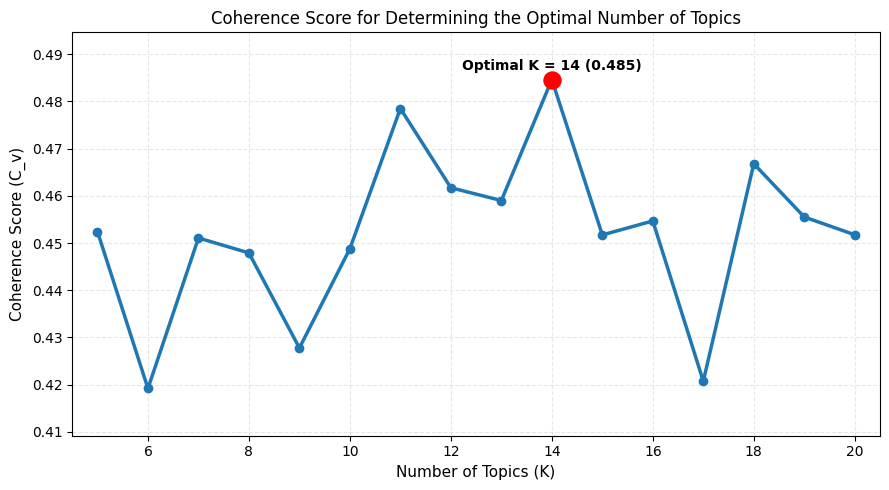

In [ ]:
# ===============================
# 4️⃣ Plot Coherence (REVISED FINAL)
# ===============================
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

# ===============================
# plot garis utama (lebih tebal & jelas)
# ===============================
plt.plot(k_values, coherence_values,
         marker='o',
         markersize=6,
         linewidth=2.5)

# ===============================
# 🔥 ambil nilai optimal (otomatis)
# ===============================
best_idx = coherence_values.index(max(coherence_values))
best_k = k_values[best_idx]
best_score = coherence_values[best_idx]

# ===============================
# 🔴 highlight titik optimal (WAJIB)
# ===============================
plt.scatter(best_k, best_score,
            s=150,            # lebih besar
            color='red',      # warna kontras
            zorder=5)

# anotasi optimal (format baru)
plt.text(best_k, best_score + 0.002,
         f"Optimal K = {best_k} ({best_score:.3f})",
         ha='center',
         fontsize=10,
         fontweight='bold')

# ===============================
# label & title (FULL ENGLISH)
# ===============================
plt.xlabel("Number of Topics (K)", fontsize=11)
plt.ylabel("Coherence Score (C_v)", fontsize=11)
plt.title("Coherence Score for Determining the Optimal Number of Topics", fontsize=12)

# ===============================
# grid lebih halus
# ===============================
plt.grid(True, linestyle="--", alpha=0.3)

# batas sumbu
plt.xlim(min(k_values)-0.5, max(k_values)+0.5)
plt.ylim(min(coherence_values)-0.01, max(coherence_values)+0.01)

plt.tight_layout()
plt.show()

In [ ]:
# ===============================
# 5️⃣ Ambil model terbaik
# ===============================
best_k = 14
best_model = model_list[k_values.index(best_k)]

print("Final K yang dipilih:", best_k)

Final K yang dipilih: 14


Meskipun nilai coherence tertinggi diperoleh pada K=5 sebesar 0.4987, model dengan K=11 dipilih karena memberikan pemisahan topik yang lebih jelas dan interpretatif. Model K=11 menunjukkan struktur tematik yang lebih kaya dan minim overlap, sehingga lebih representatif dalam menggambarkan variasi percakapan olahraga lari di media sosial X.

In [ ]:
for idx, topic in best_model.print_topics(num_topics=14, num_words=10):
    print(f"\n🔹 Topik {idx+1}:")
    print(topic)


🔹 Topik 1:
0.052*"beli" + 0.050*"sepatu" + 0.030*"sl" + 0.029*"brand" + 0.026*"celana" + 0.025*"mahal" + 0.025*"new" + 0.019*"semangat" + 0.019*"evo" + 0.018*"model"

🔹 Topik 2:
0.086*"olahraga" + 0.076*"gym" + 0.026*"tas" + 0.022*"jogging" + 0.021*"workout" + 0.020*"sepeda" + 0.020*"renang" + 0.018*"jaket" + 0.016*"senam" + 0.016*"baju"

🔹 Topik 3:
0.065*"olahraga" + 0.030*"adidas" + 0.028*"suka" + 0.018*"pilih" + 0.018*"mei" + 0.014*"kaki" + 0.013*"makanan" + 0.013*"langkah" + 0.012*"cedera" + 0.010*"x"

🔹 Topik 4:
0.091*"asics" + 0.046*"novablast" + 0.033*"gear" + 0.029*"time" + 0.024*"jogging" + 0.023*"dapet" + 0.021*"superblast" + 0.020*"pm" + 0.019*"body" + 0.018*"start"

🔹 Topik 5:
0.099*"sepatu" + 0.051*"harga" + 0.048*"olahraga" + 0.046*"shopee" + 0.046*"running" + 0.046*"dapat" + 0.039*"cek" + 0.037*"gender" + 0.037*"pria" + 0.024*"shoes"

🔹 Topik 6:
0.067*"olahraga" + 0.049*"jalan" + 0.037*"kaki" + 0.030*"pake" + 0.029*"sepatu" + 0.020*"pagi" + 0.019*"nyaman" + 0.016*"jam" 

In [ ]:
#ini topiknya menampikan sesuai k yang terpilih

topics = best_model.show_topics(num_topics=14, num_words=10, formatted=False)

for idx, topic in topics:
    words = [word for word, prob in topic]
    print(f"\n🔹 Topik {idx+1}:")
    print(", ".join(words))


🔹 Topik 1:
beli, sepatu, sl, brand, celana, mahal, new, semangat, evo, model

🔹 Topik 2:
olahraga, gym, tas, jogging, workout, sepeda, renang, jaket, senam, baju

🔹 Topik 3:
olahraga, adidas, suka, pilih, mei, kaki, makanan, langkah, cedera, x

🔹 Topik 4:
asics, novablast, gear, time, jogging, dapet, superblast, pm, body, start

🔹 Topik 5:
sepatu, harga, olahraga, shopee, running, dapat, cek, gender, pria, shoes

🔹 Topik 6:
olahraga, jalan, kaki, pake, sepatu, pagi, nyaman, jam, enak, waktu

🔹 Topik 7:
pace, main, teman, warna, foto, ajar, wts, pls, low, selamat

🔹 Topik 8:
olahraga, fomo, orang, sehat, liat, suka, ikut, ken, pagi, padel

🔹 Topik 9:
run, event, tim, komunitas, bagus, daily, kota, indonesia, recovery, olahraga

🔹 Topik 10:
fomo, real, program, nike, orange, world, week, kena, man, still

🔹 Topik 11:
day, besok, rest, mari, today, april, viral, kasih, august, minggu

🔹 Topik 12:
training, strength, latihan, support, get, blue, muscle, fat, high, year

🔹 Topik 13:
olahra

**Topic Diversity**

In [ ]:
# Ambil top words dari setiap topik
topics_words = []

for idx, topic in topics:
    words = [word for word, prob in topic]
    topics_words.append(words)

# Flatten semua kata
all_words = [word for topic in topics_words for word in topic]

# Hitung
total_words = len(all_words)
unique_words = len(set(all_words))

topic_diversity = unique_words / total_words

# Output
print("=" * 50)
print("TOPIC DIVERSITY (LDA)")
print("=" * 50)
print(f"Total words  : {total_words}")
print(f"Unique words : {unique_words}")
print(f"Diversity    : {topic_diversity:.4f}")

TOPIC DIVERSITY (LDA)
Total words  : 140
Unique words : 125
Diversity    : 0.8929


**# 🔍 INTERPRETASI LDA – K = 11**

---

## 🔹 Topik 1

**Kata kunci:**
training, strength, latih, daily, minum, air, like, real, fat, go

🏷 **Interpretasi:**
👉 **Program Latihan Harian & Asupan Dasar**

Tema ini mencerminkan:

* Latihan rutin (training, strength, latih, daily)
* Pola hidup sederhana seperti minum air
* Konteks kebugaran dan pengelolaan tubuh (fat)

Topik ini mengarah pada percakapan seputar **rutinitas latihan dan kebiasaan dasar kebugaran**, bukan spesifik ke event atau brand.

---

## 🔹 Topik 2

**Kata kunci:**
workout, x, orange, takut, women, pace, life, steps, gara, musim

🏷 **Interpretasi:**
👉 **Motivasi, Pace, dan Konteks Personal**

Tema ini agak lebih sosial dan personal karena muncul kata:

* pace
* steps
* life
* women
* takut

Kemungkinan besar ini menggambarkan percakapan tentang:

* Pengalaman berlari
* Perasaan atau motivasi pribadi
* Konteks kondisi tertentu (musim, rasa takut)

Ini bukan topik brand, tapi lebih ke **pengalaman personal dalam aktivitas olahraga**.

---

## 🔹 Topik 3

**Kata kunci:**
asics, novablast, tim, sepatu, nyaman, blue, tipe, rekomendasi, kaki, cocok

🏷 **Interpretasi:**
👉 **Review & Rekomendasi Sepatu Lari (Asics/Novablast)**

Tema sangat jelas:

* Brand spesifik (Asics, Novablast)
* Kenyamanan (nyaman, cocok)
* Diskusi tipe sepatu
* Rekomendasi

Ini topik **diskusi performa dan pengalaman penggunaan sepatu lari**.

---

## 🔹 Topik 4

**Kata kunci:**
program, nike, one, mari, muscle, back, beneran, langkah, brand, coros

🏷 **Interpretasi:**
👉 **Program Latihan & Brand Perlengkapan**

Mengandung kombinasi:

* Program
* Brand (Nike, Coros)
* Muscle
* Langkah

Kemungkinan ini percakapan tentang:

* Program latihan
* Brand wearable atau perlengkapan
* Performa

Berbeda dari Topik 3 karena lebih ke **ekosistem brand & program**, bukan hanya sepatu.

---

## 🔹 Topik 5

**Kata kunci:**
run, event, olahraga, bagus, nilai, minggu, lomba, jam, giat, gelar

🏷 **Interpretasi:**
👉 **Event & Lomba Lari**

Tema sangat jelas:

* Event
* Lomba
* Run
* Gelar
* Minggu

Ini menggambarkan percakapan tentang:

* Event lari
* Penyelenggaraan lomba
* Aktivitas kompetitif

---

## 🔹 Topik 6

**Kata kunci:**
olahraga, jalan, kaki, sehat, rutin, makan, minggu, pas, abis, badan

🏷 **Interpretasi:**
👉 **Gaya Hidup Sehat & Aktivitas Harian**

Berbeda dari Topik 1 karena:

* Lebih umum
* Tidak spesifik ke training
* Lebih ke keseharian (jalan kaki, makan, badan)

Ini tema **olahraga sebagai gaya hidup sehat**, bukan performa.

---

## 🔹 Topik 7

**Kata kunci:**
day, sepatu, tas, support, beli, time, model, rest, pinggang, wts

🏷 **Interpretasi:**
👉 **Aksesori & Aktivitas Jual-Beli Perlengkapan**

Kata penting:

* beli
* wts (want to sell)
* model
* tas
* sepatu

Ini kuat mengarah ke:

* Transaksi perlengkapan
* Marketplace informal
* Diskusi model produk

Berbeda dari Topik 8 karena lebih ke **jual-beli komunitas**.

---

## 🔹 Topik 8

**Kata kunci:**
sepatu, olahraga, harga, shopee, dapat, running, cek, gym, pria, wanita

🏷 **Interpretasi:**
👉 **Marketplace & Harga Sepatu Olahraga**

Sangat jelas komersial:

* harga
* shopee
* pria/wanita
* cek

Ini topik **perdagangan online dan promosi produk olahraga**.

---

## 🔹 Topik 9

**Kata kunci:**
besok, olahraga, body, kali, semangat, jalan, dipake, ajak, speed, lokal

🏷 **Interpretasi:**
👉 **Motivasi Harian & Aktivitas Spontan**

Tema ini menunjukkan:

* Ajakan olahraga
* Semangat
* Aktivitas besok
* Speed

Kemungkinan besar ini percakapan ringan tentang **ajakan dan semangat berolahraga**.

---

## 🔹 Topik 10

**Kata kunci:**
fomo, orang, ikut, org, liat, gapapa, mas, doang, sehat, ken

🏷 **Interpretasi:**
👉 **Fenomena FOMO dalam Olahraga**

Ini sangat sosial:

* fomo
* ikut
* orang
* liat

Menggambarkan:

* Ikut tren
* Pengaruh sosial
* Motivasi eksternal

Ini topik yang kuat secara sosiologis dan menarik untuk analisis.

---

## 🔹 Topik 11

**Kata kunci:**
olahraga, pake, suka, orang, sepatu, main, pagi, enak, gym, bikin

🏷 **Interpretasi:**
👉 **Pengalaman Umum & Preferensi Olahraga**

Tema ini lebih umum dan natural:

* suka
* enak
* pagi
* gym
* sepatu

Ini menggambarkan **preferensi dan pengalaman personal terhadap aktivitas olahraga**.

---

# 🎯 ANALISIS STRUKTUR BESAR

Kalau dikelompokkan secara makro:

1. 🏋️ Latihan & Program → Topik 1, 4
2. 👟 Sepatu & Brand → Topik 3
3. 🛒 Marketplace & Transaksi → Topik 7, 8
4. 🏁 Event & Lomba → Topik 5
5. ❤️ Gaya Hidup & Motivasi → Topik 6, 9, 11
6. 🌍 Fenomena Sosial → Topik 10
7. 👤 Pengalaman Personal → Topik 2

Ini menunjukkan bahwa percakapan lari di X tidak hanya tentang event, tetapi juga:

* Komersialisasi
* Brand engagement
* Gaya hidup
* Tekanan sosial (FOMO)



**Nilai CV tertinggi kedua** (k topik = 18)

In [ ]:
for idx, topic in secondbest_model.print_topics(num_topics=11, num_words=10):
    print(f"\n🔹 Topik {idx+1}:")
    print(topic)


🔹 Topik 1:
0.148*"training" + 0.129*"strength" + 0.025*"latih" + 0.019*"daily" + 0.018*"minum" + 0.018*"air" + 0.018*"like" + 0.018*"real" + 0.016*"fat" + 0.014*"go"

🔹 Topik 2:
0.040*"workout" + 0.024*"x" + 0.022*"orange" + 0.017*"takut" + 0.016*"women" + 0.016*"pace" + 0.014*"life" + 0.014*"steps" + 0.014*"gara" + 0.014*"musim"

🔹 Topik 3:
0.054*"asics" + 0.033*"novablast" + 0.031*"tim" + 0.021*"sepatu" + 0.020*"nyaman" + 0.015*"blue" + 0.014*"tipe" + 0.013*"rekomendasi" + 0.013*"kaki" + 0.013*"cocok"

🔹 Topik 4:
0.026*"program" + 0.024*"nike" + 0.018*"one" + 0.017*"mari" + 0.017*"muscle" + 0.015*"back" + 0.014*"beneran" + 0.014*"langkah" + 0.012*"brand" + 0.012*"coros"

🔹 Topik 5:
0.054*"run" + 0.039*"event" + 0.038*"olahraga" + 0.020*"bagus" + 0.016*"nilai" + 0.014*"minggu" + 0.013*"lomba" + 0.012*"jam" + 0.011*"giat" + 0.011*"gelar"

🔹 Topik 6:
0.100*"olahraga" + 0.035*"jalan" + 0.021*"kaki" + 0.017*"sehat" + 0.013*"rutin" + 0.012*"makan" + 0.012*"minggu" + 0.012*"pas" + 0.010*"a

**🎯 TAHAP BERIKUTNYA:
📊 Analisis Distribusi Dokumen per Topik**

Kenapa ini penting?

Karena:

Kita ingin tahu topik mana paling dominan

Kita ingin tahu proporsi percakapan publik

Ini yang akan jadi insight utama penelitian

Coherence hanya memilih model.
Distribusi topik adalah isi penelitian.

**🚀 STEP 1 — Ambil Topik Dominan per Dokumen**

In [ ]:
# Ambil topik dominan setiap dokumen
doc_topics = []

for bow in corpus:
    topics = best_model.get_document_topics(bow)
    dominant_topic = max(topics, key=lambda x: x[1])[0]
    doc_topics.append(dominant_topic)

print("Jumlah dokumen:", len(doc_topics))
print("Contoh 10 topik pertama:", doc_topics[:10])

Jumlah dokumen: 4516
Contoh 10 topik pertama: [13, 11, 4, 0, 13, 10, 10, 13, 2, 3]


✅ STEP 2 — Masukkan ke DataFrame

In [ ]:
df_test['dominant_topic'] = doc_topics

df_test[['dominant_topic']].head()

,dominant_topic
0,13
2,11
4,4
5,0
6,13


✅ STEP 3 — Hitung Distribusi

In [ ]:
topic_distribution = df_test['dominant_topic'].value_counts().sort_index()

print("Distribusi Dokumen per Topik:\n")
print(topic_distribution)

Distribusi Dokumen per Topik:

dominant_topic
0      143
1      196
2      248
3      192
4      202
5      655
6       68
7     1293
8      232
9      478
10     102
11     200
12     379
13     128
Name: count, dtype: int64


✅ STEP 4 — Hitung Persentase

In [ ]:
topic_percentage = (topic_distribution / len(df_test)) * 100

print("\nPersentase Dokumen per Topik:\n")
print(topic_percentage.round(2))


Persentase Dokumen per Topik:

dominant_topic
0      3.17
1      4.34
2      5.49
3      4.25
4      4.47
5     14.50
6      1.51
7     28.63
8      5.14
9     10.58
10     2.26
11     4.43
12     8.39
13     2.83
Name: count, dtype: float64


Hasil analisis distribusi dokumen menunjukkan bahwa topik paling dominan adalah fenomena FOMO dalam olahraga lari dengan persentase 25.84%. Hal ini menunjukkan bahwa partisipasi dalam aktivitas lari tidak hanya dipengaruhi oleh motivasi kesehatan, tetapi juga oleh faktor sosial dan tren. Selain itu, topik event dan lomba lari (18.31%) serta pembelian sepatu melalui marketplace (18.29%) juga memiliki kontribusi signifikan dalam percakapan publik.

**📊 Ringkasan Distribusi Topik (K = 11)**

---





| Topik | Jumlah | Persentase    |
| ----- | ------ | ------------- |
| 0     | 125    | 2.77%         |
| 1     | 104    | 2.30%         |
| 2     | 209    | 4.63%         |
| 3     | 198    | 4.38%         |
| 4     | 405    | 8.97%         |
| 5     | 827    | 18.31%        |
| 6     | 205    | 4.54%         |
| 7     | 263    | 5.82%         |
| 8     | 187    | 4.14%         |
| 9     | 826    | 18.29%        |
| 10    | 1167   | **25.84%** 🥇 |

🎯 Topik Paling Dominan

🥇 Topik 10 → 25.84%
🥈 Topik 5 → 18.31%
🥉 Topik 9 → 18.29%

Tiga topik ini saja sudah mencakup:

62.44% percakapan

Artinya mayoritas diskusi terkonsentrasi pada 3 tema besar.

**🔎 Sekarang Kita Cocokkan Dengan Interpretasi Sebelumnya (K=11)**

Berdasarkan output K=11 tadi:

🔹 Topik 10
fomo, orang, ikut, org

👉 Fenomena FOMO dalam olahraga

🔥 Ini paling dominan (25.84%)
Artinya:
Percakapan olahraga lari di X sangat dipengaruhi faktor sosial dan tren.

🔹 Topik 5
run, event, olahraga, lomba

👉 Event & Lomba Lari

🔹 Topik 9
sepatu, olahraga, harga, shopee

👉 Pembelian Sepatu & Marketplace

🧠 Insight Besar Penelitian Kamu

Percakapan olahraga lari di media sosial X:

1️⃣ Didominasi faktor sosial (FOMO)
2️⃣ Diikuti event dan kompetisi
3️⃣ Diikuti konsumsi perlengkapan

Ini sangat menarik secara sosial-ekonomi.

**Visualisasi Jurnal**

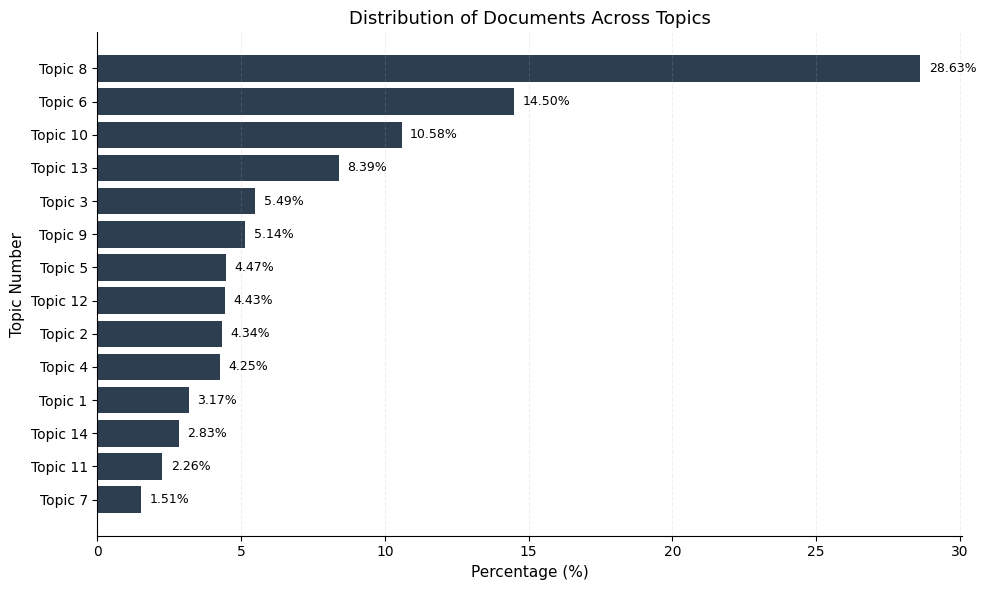

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ===============================
# Data
# ===============================
topics = [f"Topic {i}" for i in range(1, 15)]

percentages = [
    3.17, 4.34, 5.49, 4.25, 4.47, 14.50, 1.51,
    28.63, 5.14, 10.58, 2.26, 4.43, 8.39, 2.83
]

# ===============================
# DataFrame
# ===============================
df = pd.DataFrame({
    "Topic": topics,
    "Percentage": percentages
})

# Urutkan
df = df.sort_values(by="Percentage", ascending=True)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(10,6))

bars = plt.barh(
    df["Topic"],
    df["Percentage"],
    color="#2C3E50"
)

# ===============================
# Label nilai (SUDAH ADA %)
# ===============================
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}%",   # ← ini yang diubah
        va='center',
        fontsize=9
    )

# ===============================
# Title & Axis
# ===============================
plt.title("Distribution of Documents Across Topics", fontsize=13)

plt.xlabel("Percentage (%)", fontsize=11)
plt.ylabel("Topic Number", fontsize=11)

# ===============================
# Styling
# ===============================
plt.grid(axis='x', linestyle='--', alpha=0.2)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()

# ===============================
# Save
# ===============================
plt.savefig("topic_distribution_lda.png", dpi=300)

plt.show()

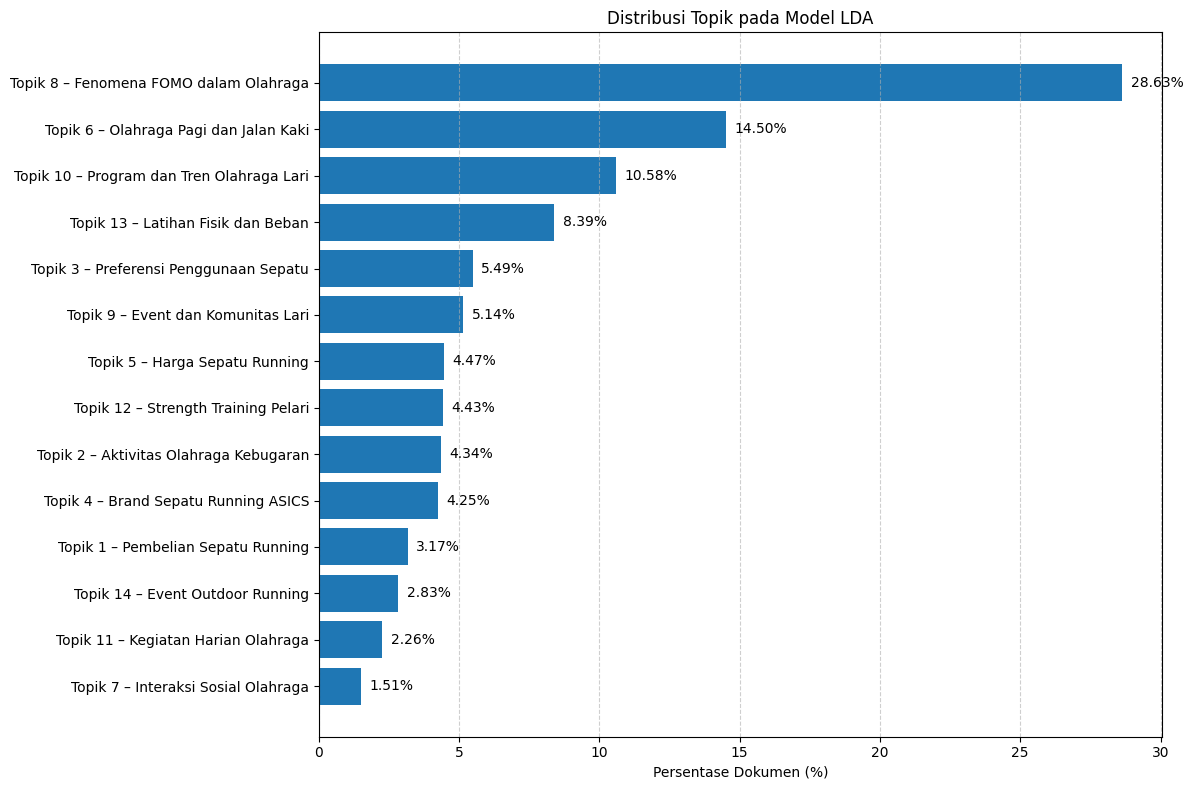

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data topik dan persentase
topics = [
"Topik 1 – Pembelian Sepatu Running",
"Topik 2 – Aktivitas Olahraga Kebugaran",
"Topik 3 – Preferensi Penggunaan Sepatu",
"Topik 4 – Brand Sepatu Running ASICS",
"Topik 5 – Harga Sepatu Running",
"Topik 6 – Olahraga Pagi dan Jalan Kaki",
"Topik 7 – Interaksi Sosial Olahraga",
"Topik 8 – Fenomena FOMO dalam Olahraga",
"Topik 9 – Event dan Komunitas Lari",
"Topik 10 – Program dan Tren Olahraga Lari",
"Topik 11 – Kegiatan Harian Olahraga",
"Topik 12 – Strength Training Pelari",
"Topik 13 – Latihan Fisik dan Beban",
"Topik 14 – Event Outdoor Running"
]

percentages = [3.17,4.34,5.49,4.25,4.47,14.50,1.51,28.63,5.14,10.58,2.26,4.43,8.39,2.83]

# Buat dataframe
df = pd.DataFrame({
    "Topik": topics,
    "Persentase": percentages
})

# Urutkan dari terbesar
df = df.sort_values(by="Persentase", ascending=True)

plt.figure(figsize=(12,8))

bars = plt.barh(df["Topik"], df["Persentase"])

plt.xlabel("Persentase Dokumen (%)")
plt.title("Distribusi Topik pada Model LDA")

# Tambahkan label nilai di batang
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}%", va='center')

# Grid ringan
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()

# Simpan gambar
plt.savefig("distribusi_topik_lda.png", dpi=300)

plt.show()

lanjut ke visualisasi

In [ ]:
# 🔇 Hilangkan warning deprecation agar output bersih
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# 📦 Install pyLDAvis (hanya perlu sekali)
!pip install pyLDAvis

# 📚 Import library yang dibutuhkan
import gensim
import pyLDAvis
import pyLDAvis.gensim_models


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Asumsi: model LDA kamu sudah bernama 'lda_model'
# dan corpus + dictionary sudah ada
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
7      0.170416 -0.136946       1        1  19.302855
5      0.219847  0.030035       2        1  13.557131
12     0.157759 -0.099327       3        1  10.339378
4      0.054988  0.317584       4        1   7.049050
2      0.162979 -0.087974       5        1   6.634620
1      0.085248  0.141184       6        1   6.449481
8      0.002355 -0.119953       7        1   6.136916
9     -0.150027 -0.173935       8        1   5.580437
0      0.008803  0.153897       9        1   5.069160
13     0.010237 -0.002810      10        1   4.597561
3     -0.216755 -0.011839      11        1   4.333170
11    -0.237902  0.105479      12        1   4.289321
10    -0.174916 -0.023177      13        1   3.441656
6     -0.093031 -0.092217      14        1   3.219263, topic_info=          Term         Freq        Total Category  logprob  loglift
765       fomo  1007.000000  1007.000000  Default  30.0000  30.0000
552   training   353.000000   353.000000  Default  29.0000  29.0000
219     sepatu   573.000000   573.000000  Default  28.0000  28.0000
1260  strength   264.000000   264.000000  Default  27.0000  27.0000
62         run   251.000000   251.000000  Default  26.0000  26.0000
...        ...          ...          ...      ...      ...      ...
79        aman    19.359632    53.648775  Topic14  -4.2664   2.4167
322       moga    18.978297    65.427225  Topic14  -4.2863   2.1984
127    manfaat    18.020492   119.549619  Topic14  -4.3381   1.5438
1361     susah    13.513064    26.377426  Topic14  -4.6259   2.7672
553    jakarta    13.440129    30.085230  Topic14  -4.6313   2.6302

[705 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
576       1  0.209398     10k
576       5  0.247471     10k
576       7  0.513978     10k
1079      2  0.982250     21k
1921      5  0.086862      3x
...     ...       ...     ...
2108      4  0.968441  yellow
512       3  0.288642    yoga
512       4  0.404099    yoga
512       5  0.144321    yoga
512       9  0.144321    yoga

[981 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 6, 13, 5, 3, 2, 9, 10, 1, 14, 4, 12, 11, 7])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**📌 Menampilkan Contoh Dokumen per Topik** - validasi kualitatif

-ni penting karena:

* Membuktikan topik memang sesuai konteks

* Menghindari interpretasi salah

* Menguatkan Bab IV

* Disukai dosen pembimbing

**🎯 STEP 1 — Tampilkan 5 Contoh Tweet per Topik**  - Kita ambil dari kolom lower (yang sudah dibersihkan struktur kasarnya).

In [ ]:
# Ambil distribusi topik lengkap per dokumen
doc_topic_probs = []

for bow in corpus:
    topic_probs = best_model.get_document_topics(bow)
    doc_topic_probs.append(dict(topic_probs))

# Ubah ke DataFrame
topic_prob_df = pd.DataFrame(doc_topic_probs).fillna(0)

# Gabungkan dengan df_test
df_analysis = df_test.copy().reset_index(drop=True)
df_analysis = pd.concat([df_analysis, topic_prob_df], axis=1)

In [ ]:
for topic_num in range(best_k):
    print("\n==============================")
    print(f"🔹 TOPIK {topic_num}")
    print("==============================")

    top_docs = df_analysis.sort_values(by=topic_num, ascending=False).head(5)

    for i, row in top_docs.iterrows():
        print(f"\nProb: {row[topic_num]:.4f}")
        print(row['lower'])


🔹 TOPIK 0

Prob: 0.9303
new listing alert!

https://t.co/xfr8g9wlff has officially listed lair finance (lair) for spot trading!
trading starts: april 25, 2025, 09:00 (utc)

plus, don’t miss the airdrop!
stake lair/btc/usdt in the $lair launchpool and earn your share of 3,500,000 lair — rewards dropping https://t.co/rnjpq1y7zt

Prob: 0.9269
massive news — https://t.co/e5fznlhzia just lit it up!

lair finance $lair is officially live for  trading!

trading started: april 25, 2025 @ 09:00 utc — and it’s already getting wild.

launchpool is in full swing:

phase 2: 
stake from april 25 @ 09:00 to may 5 @ 09:00 (utc) https://t.co/loteyrblg0

Prob: 0.9094
lisachella 3 days to go🔥

🗓️ friday | 11 &amp; 18.04.2025🇺🇸
📍 sahara tent
⏰ 7.45 pm - 8.40 pm🇺🇸

🗓️ saturday | 12 &amp; 19.04.2025🇹🇭
📍 sahara tent
⏰ 9.45 pm - 10.40 pm🇹🇭

#lisa #lalisa
#lalisamanobal 
#lisaxalterego
#coachella2025 
@wearelloud 
🧁🌟 https://t.co/ep9bb569gw

Prob: 0.9036
lisachella 5 days to go🔥

🗓️ friday | 11 &amp; 18.04.20

In [ ]:
# 🔇 Hilangkan warning deprecation agar output bersih
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# 📦 Install pyLDAvis (hanya perlu sekali)
!pip install pyLDAvis

# 📚 Import library yang dibutuhkan
import gensim
import pyLDAvis
import pyLDAvis.gensim_models


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Asumsi: model LDA kamu sudah bernama 'lda_model'
# dan corpus + dictionary sudah ada
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.009815 -0.107128       1        1  17.349491
2      0.085455 -0.091613       2        1  14.703187
7      0.128305  0.045595       3        1  11.973576
6     -0.048514  0.119829       4        1  11.588327
4     -0.131002 -0.059977       5        1  11.195488
0     -0.027699 -0.014643       6        1  10.485667
9      0.051342  0.058048       7        1   7.323999
5      0.021428 -0.013896       8        1   6.712711
8     -0.060625  0.008827       9        1   5.796876
3     -0.028504  0.054959      10        1   2.870678, topic_info=         Term        Freq       Total Category  logprob  loglift
8    motivasi   67.000000   67.000000  Default  30.0000  30.0000
55      jalan   41.000000   41.000000  Default  29.0000  29.0000
63   olahraga   42.000000   42.000000  Default  28.0000  28.0000
41      hidup   14.000000   14.000000  Default  27.0000  27.0000
6        lari  208.000000  208.000000  Default  26.0000  26.0000
..        ...         ...         ...      ...      ...      ...
258    stamen    0.446324    3.216385  Topic10  -5.4711   1.5757
262     event    0.446324   14.255072  Topic10  -5.4711   0.0868
267    target    0.446324    2.533618  Topic10  -5.4711   1.8143
289     perut    0.446324    3.172128  Topic10  -5.4711   1.5895
492     kasut    0.446324    5.493885  Topic10  -5.4711   1.0403

[585 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
195       1  0.297563      a
195       3  0.297563      a
195       4  0.297563      a
360       4  0.228811  acara
360       6  0.228811  acara
...     ...       ...    ...
774       1  0.564655      x
774       5  0.376437      x
35        2  0.669052   your
578       1  0.881522  yudha
775       5  0.945984    zon

[860 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 8, 7, 5, 1, 10, 6, 9, 4])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**🧮 Step 9 — Mengukur Nilai Koherensi (C_v)**

dibawah ini adalah code baru **baru**

**dibawah ini adalah code lama**

In [ ]:
import warnings, logging
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger("py4j").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

from gensim.models import CoherenceModel

coherence_model_lda = CoherenceModel(
    model=lda_model,
    texts=tokenized_texts,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_lda = coherence_model_lda.get_coherence()

print(f"📊 Nilai Coherence (C_v): {coherence_lda:.4f}")


📊 Nilai Coherence (C_v): 0.5393


In [ ]:
coherence_model_lda = CoherenceModel(
    model=lda_model,
    texts=tokenized_texts,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_lda = coherence_model_lda.get_coherence()

print(f"📊 Nilai Coherence (C_v): {coherence_lda:.4f}")

📊 Nilai Coherence (C_v): 0.5393


Nilai Coherence (C_v) = 0.4439 artinya model LDA kamu sudah cukup koheren, tapi masih bisa ditingkatkan dengan tuning jumlah topik dan penyesuaian preprocessing.

📖 Interpretasi Nilai 0.4439:
Nilai C_v	Kualitas Topik	Keterangan
* 0.0 – 0.30	Buruk	Topik acak, belum terstruktur
* 0.30 – 0.50	Cukup Baik ✅	Topik mulai terpisah, tapi masih tumpang tindih
* 0.50 – 0.65	Baik	Struktur topik sudah jelas
* diatas 0.65	Sangat Baik	Topik sangat terdefinisi & konsisten

Jadi saat ini:

💬 Model kamu sudah bisa digunakan untuk analisis awal, tapi belum ideal untuk hasil akhir skripsi — masih bisa di-tuning supaya C_v naik.

**⚙️ Step 10 — Tuning Jumlah Topik (Cari Nilai C_v Terbaik)**

* Sekarang kita akan mencoba berbagai jumlah topik (misalnya 2–10) dan hitung nilai C_v untuk masing-masing.
Tujuannya adalah mencari jumlah topik paling optimal (yang menghasilkan C_v tertinggi).

In [ ]:
from gensim.models import LdaModel, CoherenceModel
import numpy as np

def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    model_list = []

    for num_topics in range(start, limit, step):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=20,
            alpha=0.1,         # 🔹 ubah dari 'auto' ke nilai kecil tetap
            eta=0.1,           # 🔹 tambahkan eta untuk kestabilan distribusi kata
            per_word_topics=False  # 🔹 nonaktifkan untuk dataset kecil
        )

        model_list.append(model)

        coherencemodel = CoherenceModel(
            model=model, texts=texts, dictionary=dictionary, coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values


# Jalankan ulang dengan versi stabil
start, limit, step = 1, 11, 1

model_list, coherence_values = compute_coherence_values(dictionary, corpus, tokenized_texts, start, limit, step)

# Hasilkan nilai coherence
for m, cv in zip(range(start, limit, step), coherence_values):
    print(f"Jumlah Topik = {m}, Coherence Score = {cv:.4f}")


Jumlah Topik = 1, Coherence Score = 0.3609
Jumlah Topik = 2, Coherence Score = 0.4144
Jumlah Topik = 3, Coherence Score = 0.4337
Jumlah Topik = 4, Coherence Score = 0.4353
Jumlah Topik = 5, Coherence Score = 0.4945
Jumlah Topik = 6, Coherence Score = 0.4531
Jumlah Topik = 7, Coherence Score = 0.4919
Jumlah Topik = 8, Coherence Score = 0.4398
Jumlah Topik = 9, Coherence Score = 0.4445
Jumlah Topik = 10, Coherence Score = 0.5228


**VISUALISASI UNTUK TAMBAHAN**

**interpretasi** :

Dari grafik di atas, terlihat bahwa nilai Coherence Score cenderung berfluktuasi pada rentang 0.43–0.54.
Nilai tertinggi diperoleh pada jumlah topik = 1 dengan Coherence Score = 0.5391, diikuti oleh jumlah topik = 9 dengan Coherence Score = 0.5373.
Walaupun model dengan satu topik memberikan koherensi paling tinggi, model tersebut cenderung terlalu umum (kurang mampu menangkap variasi tema).
Oleh karena itu, model dengan 9 topik dipilih karena memberikan keseimbangan antara nilai koherensi yang tinggi dan keragaman topik yang lebih kaya secara semantik.

**Visualisasi WORDCLOUD**

In [ ]:
!pip install wordcloud

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

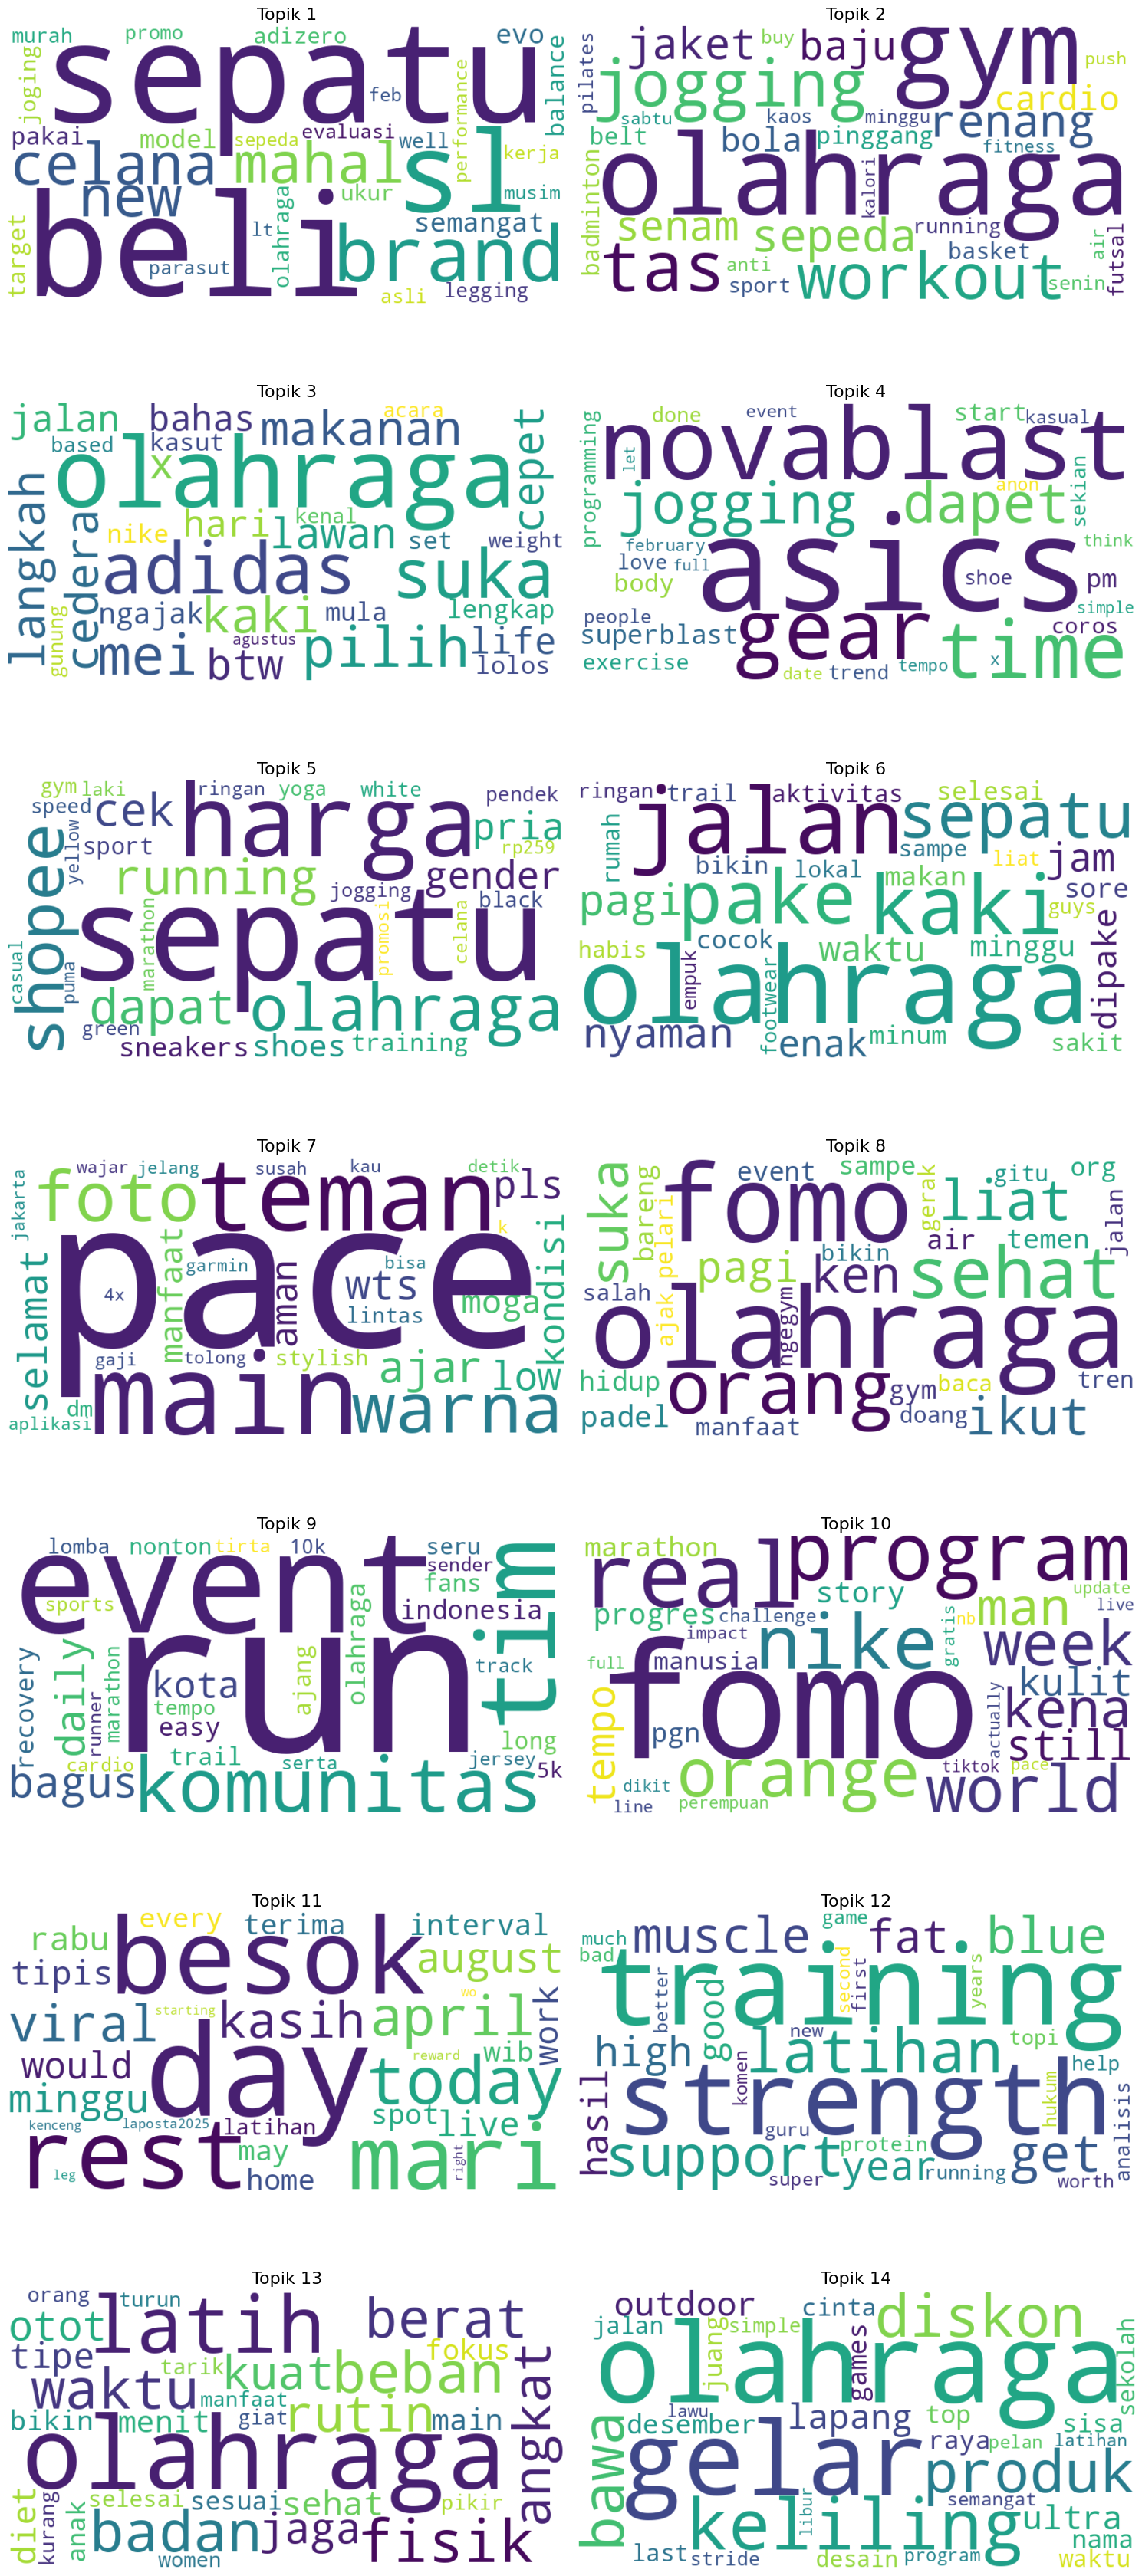

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil semua topik dari model LDA
topics = best_model.show_topics(
    num_topics=best_model.num_topics,
    num_words=30,
    formatted=False
)

num_topics = len(topics)

cols = 2
rows = (num_topics + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(15, rows*5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num_topics:
        topic_words = dict(topics[i][1])

        wc = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='viridis',
            max_words=30,
            random_state=42
        ).generate_from_frequencies(topic_words)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f"Topik {i+1}", fontsize=16)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

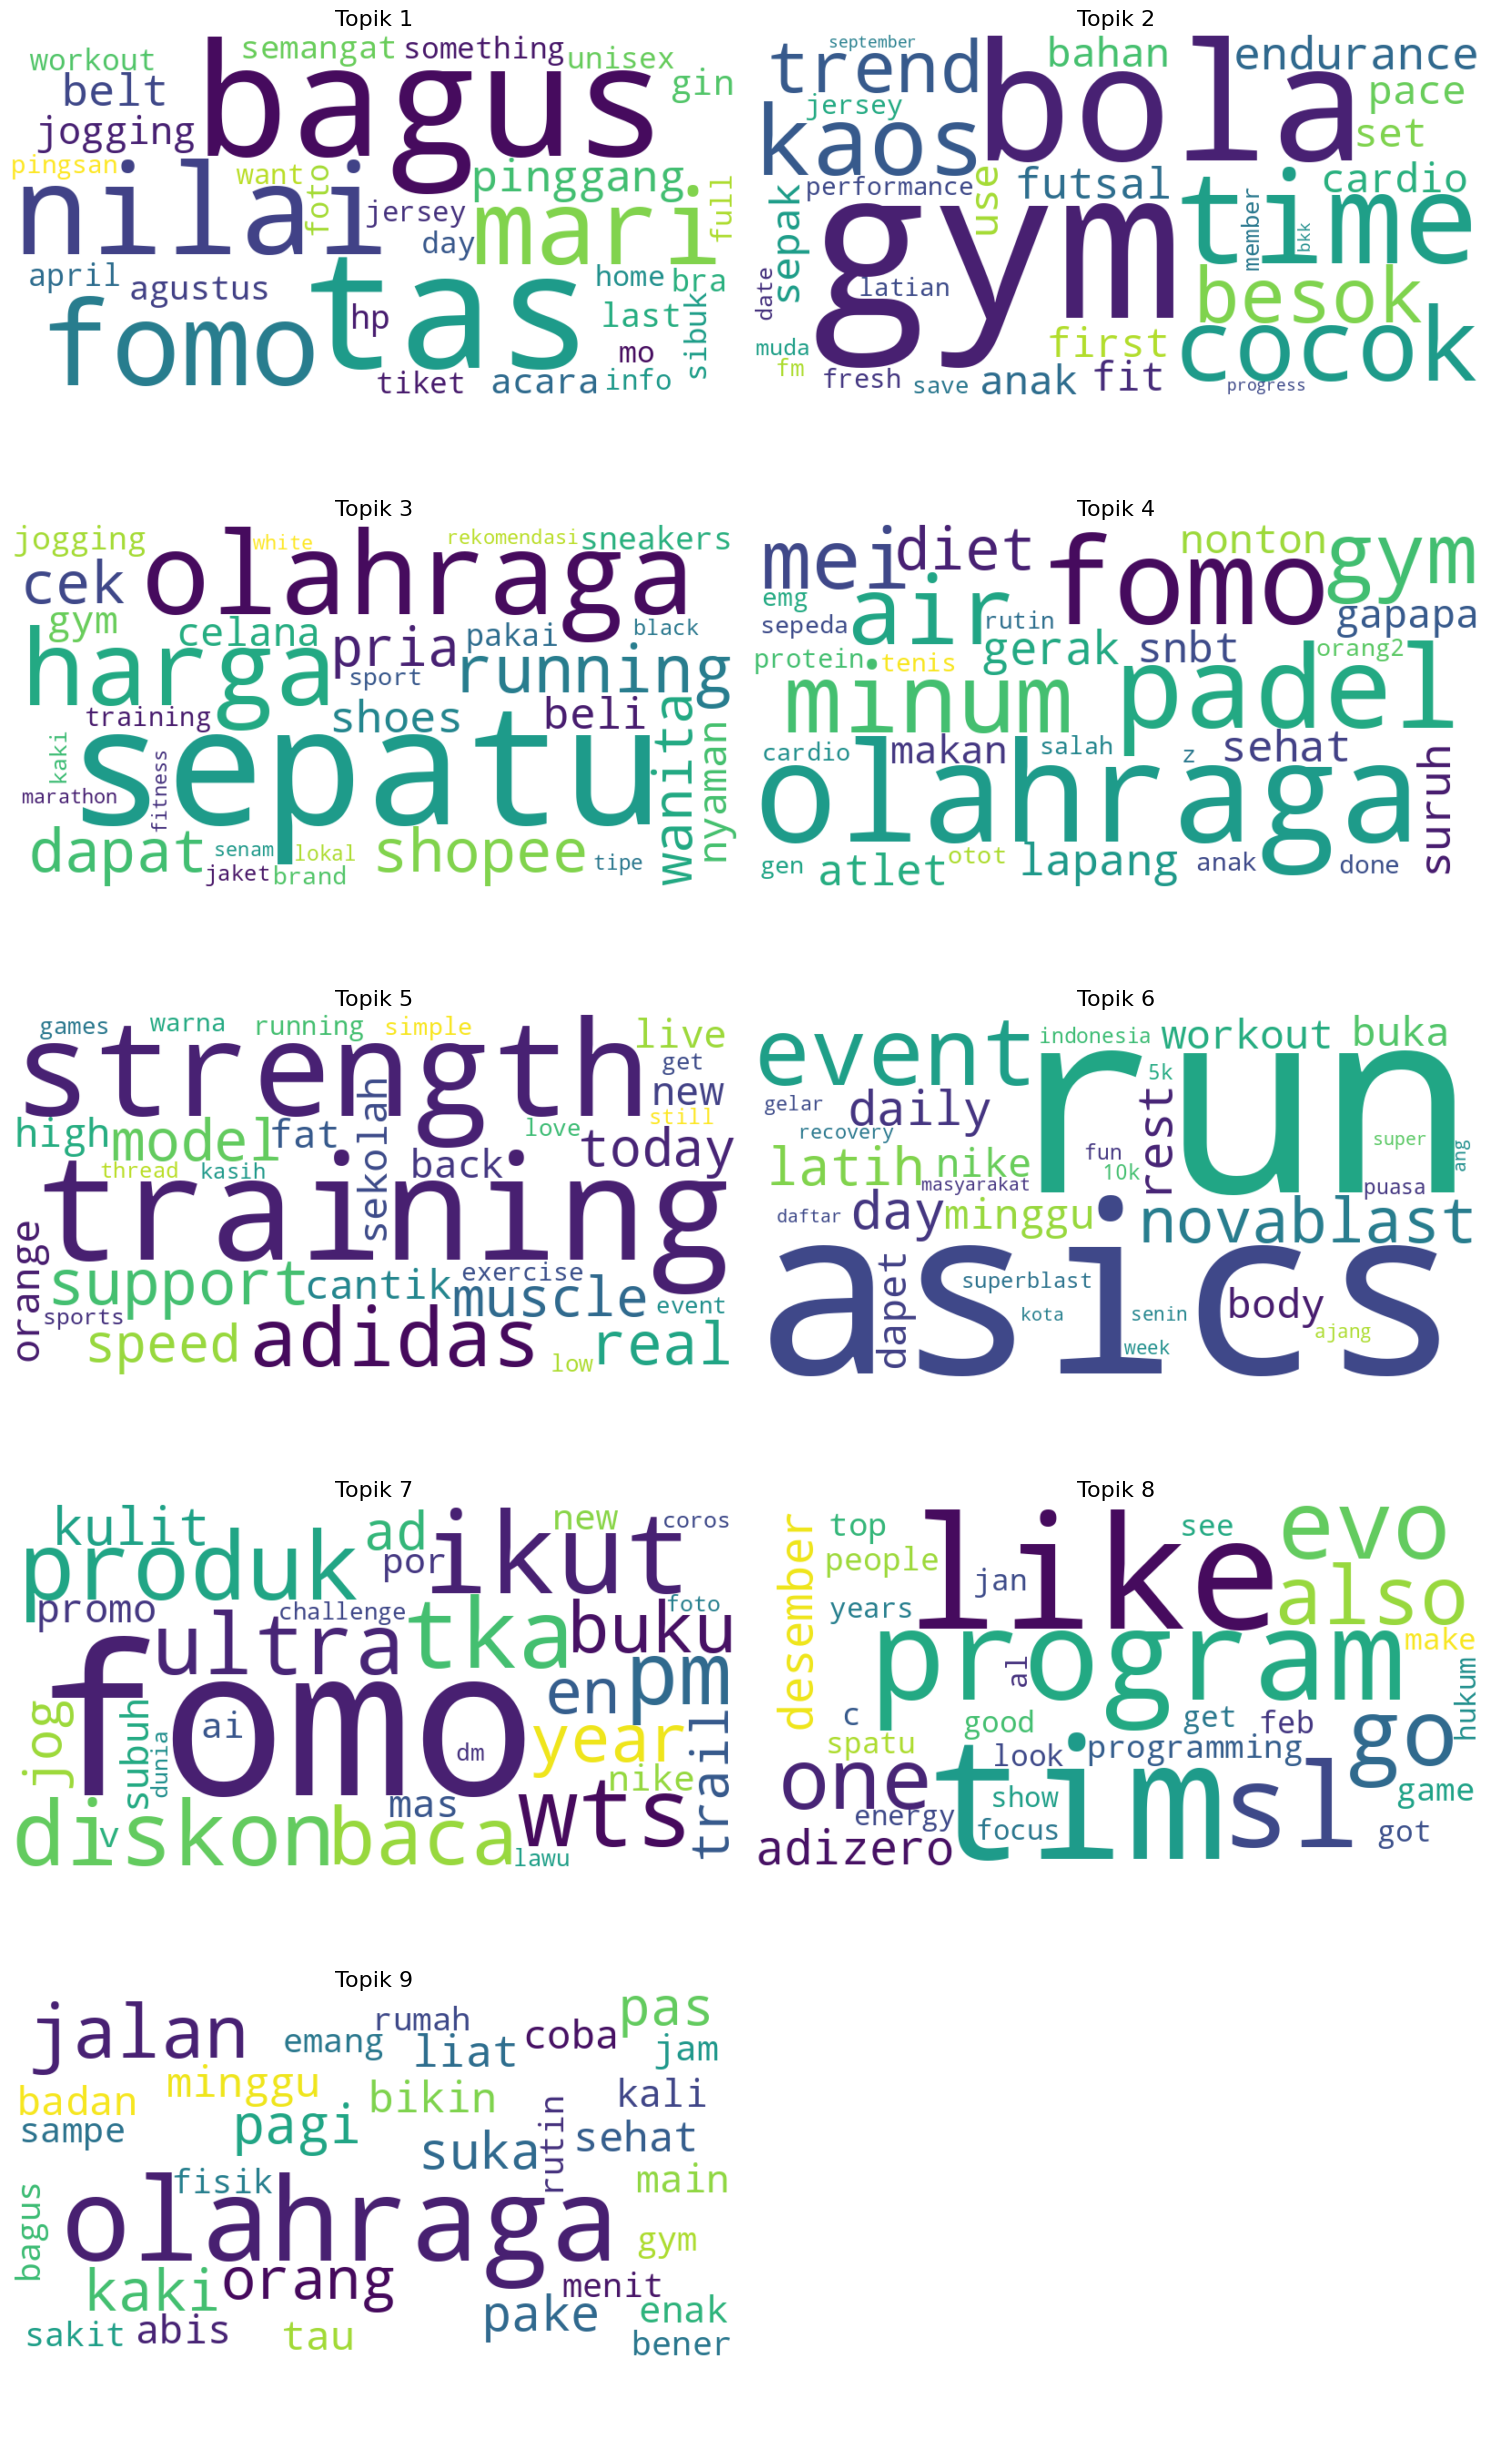

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil semua topik dari model LDA
topics = best_model.show_topics(
    num_topics=best_model.num_topics,
    num_words=30,
    formatted=False
)

num_topics = len(topics)

cols = 2
rows = (num_topics + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(15, rows*5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num_topics:
        topic_words = dict(topics[i][1])

        wc = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='viridis',
            max_words=30,
            random_state=42
        ).generate_from_frequencies(topic_words)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f"Topik {i+1}", fontsize=16)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

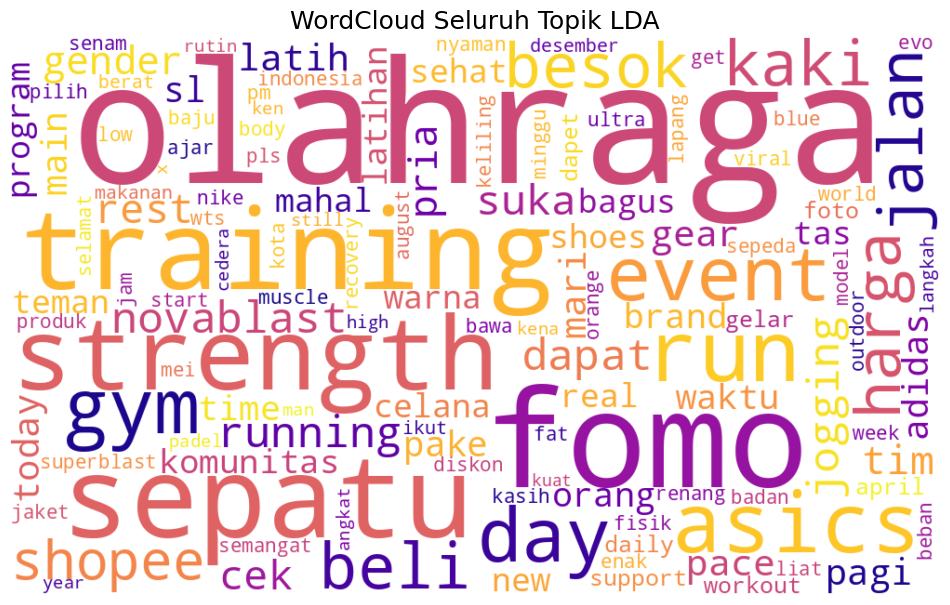

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil semua topik dari model LDA
topics = best_model.show_topics(num_topics=best_model.num_topics, formatted=False)

# Gabungkan semua kata dari seluruh topik
all_topic_words = {}

for topic in topics:
    for word, prob in topic[1]:
        all_topic_words[word] = all_topic_words.get(word, 0) + prob

# Buat WordCloud
wc = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='plasma',
).generate_from_frequencies(all_topic_words)

# Visualisasi
plt.figure(figsize=(12,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Seluruh Topik LDA", fontsize=18)
plt.show()

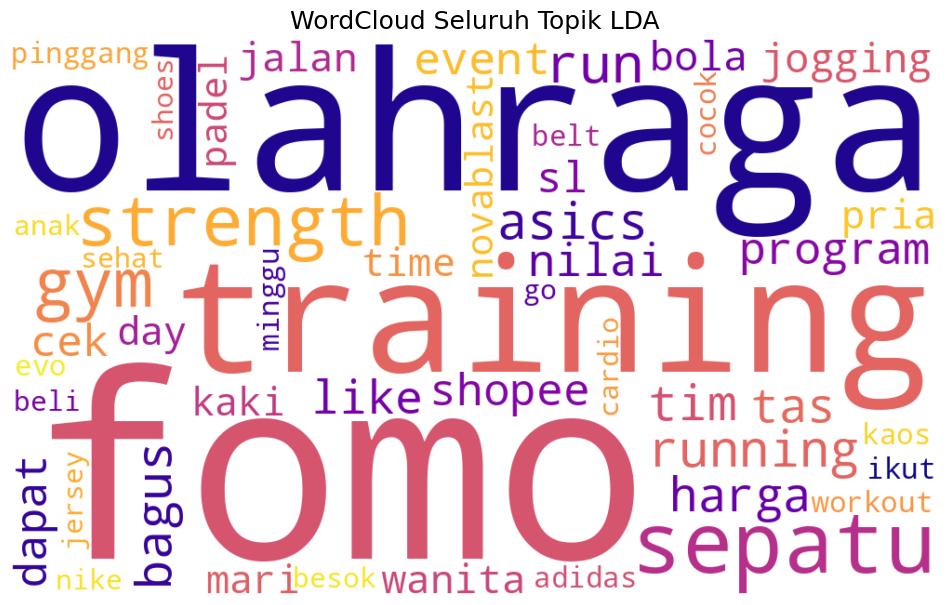

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil semua topik dari model LDA (lebih banyak kata)
topics = best_model.show_topics(
    num_topics=best_model.num_topics,
    num_words=30,
    formatted=False
)

# Gabungkan semua kata dari seluruh topik
all_topic_words = {}

for topic in topics:
    for word, prob in topic[1]:
        all_topic_words[word] = all_topic_words.get(word, 0) + prob

# Buat WordCloud
wc = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='plasma',
    max_words=50,
    random_state=42
).generate_from_frequencies(all_topic_words)

# Visualisasi
plt.figure(figsize=(12,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Seluruh Topik LDA", fontsize=18)
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil top 10 topik dari model LDA
topics = best_model.show_topics(formatted=False)

# Tampilkan wordcloud untuk setiap topik
fig, axes = plt.subplots(5, 2, figsize=(15, 25))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(topics):
        topic_words = dict(topics[i][1])
        wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis')
        wc.generate_from_frequencies(topic_words)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f"Topik {i+1}", fontsize=16)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
all_words = ' '.join([' '.join(tokens) for tokens in text4])

wc_all = WordCloud(width=1000, height=600, background_color='white', colormap='plasma').generate(all_words)
plt.figure(figsize=(12, 8))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Seluruh Tweet', fontsize=18)
plt.show()


NameError: name 'text4' is not defined

**INTERPRETASI :**
Wordcloud di atas menggambarkan distribusi kata paling dominan dalam masing-masing topik yang dihasilkan oleh model LDA.
Ukuran kata menunjukkan tingkat frekuensi atau bobot kemunculan kata pada topik tersebut.
Kata “lari” dan “olahraga” tampak dominan di sebagian besar topik, menandakan tema utama percakapan di Twitter berfokus pada aktivitas olahraga, terutama lari.
